In [83]:
import pandas as pd
import numpy as np
from scipy.special import expit 
import kaleido
import nbformat
import seaborn as sns
import matplotlib.pyplot as plt
import shap

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import LabelEncoder

In [ ]:
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
from imblearn.over_sampling import SMOTE

In [4]:
rng = np.random.default_rng(42)

# ============================
# 0. Setup & Cleanup
# ============================

df_original = pd.read_csv("D:\\Projects\\ML\\Student Perfomance Prediction\\data\\raw\\test.csv")
print("Original Shape:", df_original.shape)

if 'Student_ID' not in df_original.columns:
    df_original['Student_ID'] = range(1, len(df_original) + 1)

df_original = df_original.dropna(subset=[
    'TestScore_Math', 'TestScore_Science', 'TestScore_Reading',
    'GPA', 'StudyHours', 'InternetAccess', 'Locale', 'AttendanceRate'
])

for col in ['TestScore_Math', 'TestScore_Science', 'TestScore_Reading', 'GPA',
            'StudyHours', 'InternetAccess', 'AttendanceRate']:
    df_original[col] = pd.to_numeric(df_original[col])

df_original['Locale'] = df_original['Locale'].astype(str).str.strip()
n_students = len(df_original)

# ============================
# 1. Student-Level Traits
# ============================

df_original['Latent_Ability'] = rng.normal(0, 1, n_students)

archetypes = ['elite', 'fading_star', 'late_bloomer', 'disengaged', 'pragmatist', 'vulnerable']
probs      = [0.12,    0.13,          0.15,           0.20,         0.18,          0.22]
df_original['Archetype'] = rng.choice(archetypes, size=n_students, p=probs)

conditions = [
    df_original['Archetype'] == 'elite',
    df_original['Archetype'] == 'fading_star',
    df_original['Archetype'] == 'late_bloomer',
    df_original['Archetype'] == 'disengaged',
    df_original['Archetype'] == 'pragmatist',
    df_original['Archetype'] == 'vulnerable'
]
df_original['Personality_Stability'] = rng.uniform(0.6, 1.0, n_students)
df_original['study_environment_score']   = np.select(conditions, [8.5,7.5,7.0,5.5,7.2,6.2]) + rng.normal(0,0.8,n_students)
df_original['first_generation_college_flag'] = np.select(conditions, [0,0,0,1,0,1])
df_original['procrastination_tendency'] = np.select(conditions, [2.0,3.5,3.0,7.0,4.0,5.5]) + rng.normal(0,0.7,n_students)
df_original['stress_survey_score']      = np.select(conditions, [4.5,6.0,5.5,7.0,5.8,7.5]) + rng.normal(0,0.8,n_students)
df_original['exam_anxiety_score']       = np.select(conditions, [3.0,5.0,4.5,6.5,4.5,7.0]) + rng.normal(0,0.7,n_students)
df_original['motivation_survey_score']  = np.select(conditions, [8.5,6.0,8.0,3.5,6.5,5.5]) + rng.normal(0,0.7,n_students)
df_original['sleep_hours']              = np.select(conditions, [7.5,6.8,7.2,6.0,6.8,6.5]) + rng.normal(0,0.5,n_students)
df_original['self_efficacy_score']      = np.select(conditions, [8.5,6.0,7.5,4.0,6.5,5.0]) + rng.normal(0,0.7,n_students)
df_original['goal_clarity_survey_score']= np.select(conditions, [8.5,5.5,7.8,3.5,6.5,5.0]) + rng.normal(0,0.7,n_students)

locale_map = {'Rural': 3, 'Town': 2, 'Suburban': 2, 'City': 1}
df_original['Commute_Strain'] = df_original['Locale'].map(locale_map).fillna(2)

# ============================
# 2. Longitudinal Expansion
# ============================

df_original = df_original.loc[df_original.index.repeat(8)].reset_index(drop=True)
df_original['Semester_ID'] = np.tile(range(1, 9), n_students)

df_original['Prev_GPA']       = 0.0
df_original['Final_Sem_GPA']  = 0.0
df_original['Backlog_Count']  = 0

# Reduce memory footprint
float_cols = df_original.select_dtypes(include=['float64']).columns
df_original[float_cols] = df_original[float_cols].astype('float32')

int_cols = df_original.select_dtypes(include=['int64']).columns
df_original[int_cols] = df_original[int_cols].astype('int32')

# ============================
# NEW: Columns for all 5 features
# ============================

# Archetype transitions
df_original['Archetype_Prev']        = df_original['Archetype']
df_original['Archetype_Transition']  = 'none'      # label of what changed

# Interventions
df_original['Intervention_Applied']  = 'none'      # 'counseling','academic_warning','mentorship','none'
df_original['Intervention_Active']   = 0           # 1 if intervention is in effect this sem

# Motivation dynamics
df_original['Dynamic_Motivation']    = df_original['motivation_survey_score'].clip(1, 10)
df_original['Dynamic_Confidence']    = df_original['self_efficacy_score'].clip(1, 10)
df_original['Dynamic_Burnout']       = 0.0         # cumulative burnout score

# Shock events
df_original['Shock_Event']           = 'none'
df_original['Shock_Magnitude']       = 0.0

# ============================
# 3. Archetype Transition Rules (Probabilistic Matrix)
# ============================
def vectorized_transitions(cur_arch, mot, bur, strss, conf, gpa_trend, backlogs, intv, shock_neg, rng):
    n = len(cur_arch)
    arch_list = ['elite', 'fading_star', 'late_bloomer', 'disengaged', 'pragmatist', 'vulnerable']
    arch_idx = {a: i for i, a in enumerate(arch_list)}
    
    # Start with an empty weight matrix [n_students, 6]
    weights = np.zeros((n, len(arch_list)))
    
    # IMPROVEMENT 3: Add archetype persistence
    stay_prob = 0.85
    current_indices = np.array([arch_idx[a] for a in cur_arch])
    weights[np.arange(n), current_indices] = stay_prob

    def add_weight(from_a, to_a, weight_val, cond_mask):
        """Adds weight to a specific target archetype if conditions are met."""
        trigger = (cur_arch == from_a) & cond_mask
        weights[trigger, arch_idx[to_a]] += weight_val

    # ── REALISTIC WEIGHTS (These add to the distribution, no first-match bias) ──
    add_weight("late_bloomer", "elite",       0.15, (mot > 7.5) & (gpa_trend > 0.3))
    add_weight("late_bloomer", "elite",       0.12, (conf > 8.0) & (gpa_trend > 0.4))
    add_weight("late_bloomer", "pragmatist",  0.10, (gpa_trend > 0))
    add_weight("elite",        "fading_star", 0.15, (bur > 4.0) | (strss > 8.0))
    add_weight("elite",        "fading_star", 0.12, (conf < 5.0) & (bur > 3.5))
    add_weight("elite",        "pragmatist",  0.10, (bur > 3.0))
    add_weight("fading_star",  "vulnerable",  0.20, (bur > 5.0) & (backlogs > 2))
    add_weight("fading_star",  "pragmatist",  0.15, (gpa_trend > -0.1))
    add_weight("pragmatist",   "late_bloomer",0.12, (mot > 7.0))
    add_weight("pragmatist",   "fading_star", 0.10, (bur > 4.5))
    add_weight("vulnerable",   "pragmatist",  0.15, (mot > 5.5) & (backlogs < 2))
    add_weight("vulnerable",   "disengaged",  0.25, (mot < 3.5) & (strss > 7.5))
    add_weight("vulnerable",   "late_bloomer",0.10, (conf > 6.5) & (mot > 6.0))
    
    # Normalize weights so each student's row sums to 1.0
    row_sums = weights.sum(axis=1, keepdims=True)
    probs = weights / row_sums
    
    # Vectorized random choice based on individual probability distributions
    cum_probs = probs.cumsum(axis=1)
    rolls = rng.random((n, 1))
    chosen_indices = (rolls < cum_probs).argmax(axis=1)
    
    new_arch = np.array([arch_list[i] for i in chosen_indices])
    labels = np.where(cur_arch != new_arch, cur_arch + "→" + new_arch, 'none')
    
    return new_arch, labels


# ============================
# 4. Shock Event Catalogue
# ============================
SHOCK_EVENTS = [
    # (name,                   prob,  attendance_Δ, study_Δ, motivation_Δ, burnout_Δ, neg_flag)
    ("family_issue",           0.05,  -0.10,       -0.8,    -1.5,         +0.8,      True),
    ("health_problem",         0.04,  -0.12,       -1.0,    -1.2,         +0.6,      True),
    ("financial_stress",       0.04,  -0.05,       -0.5,    -1.0,         +0.5,      True),
    ("breakup",                0.06,  -0.04,       -0.6,    -1.8,         +0.4,      True),
    ("part_time_job_increase", 0.05,  -0.06,       -0.7,    -0.5,         +0.3,      True),
    ("competition_success",    0.04,  +0.02,       +0.5,    +2.0,         -0.3,      False),
    ("scholarship_award",      0.03,  +0.01,       +0.6,    +1.8,         -0.2,      False),
    ("mentorship_start",       0.04,  +0.02,       +0.4,    +1.5,         -0.4,      False),
    ("bereavement",            0.02,  -0.15,       -1.2,    -2.0,         +1.0,      True),
    ("academic_achievement",   0.04,  +0.01,       +0.3,    +1.5,         -0.2,      False),
]

# Separate out for weighted choice
SHOCK_NAMES = [e[0] for e in SHOCK_EVENTS]
SHOCK_PROBS = np.array([e[1] for e in SHOCK_EVENTS])

# Normalize automatically to prevent invalid distributions
total_prob = SHOCK_PROBS.sum()

if total_prob >= 1.0:
    SHOCK_PROBS = SHOCK_PROBS / (total_prob + 0.01)

P_NONE = max(0.0, 1.0 - SHOCK_PROBS.sum())

SHOCK_CHOICES = SHOCK_NAMES + ['none']
SHOCK_WEIGHTS = np.append(SHOCK_PROBS, P_NONE)

SHOCK_WEIGHTS = SHOCK_WEIGHTS / SHOCK_WEIGHTS.sum()

# Lookup dictionary for fast access
SHOCK_DICT = {e[0]: e[1:] for e in SHOCK_EVENTS}


# ============================
# 5. Intervention Trigger Logic
# ============================
def should_trigger_intervention(gpa: float, backlogs: int, motivation: float,
                                 attendance: float, sem: int, rng: np.random.Generator
                                 ) -> tuple[str, dict]:
    # Lowered probabilities to 0.15 - 0.25
    if (gpa < 4.5 or backlogs >= 3) and rng.random() < 0.25:
        return "academic_warning", {"motivation_Δ": +0.8, "burnout_Δ": -0.3, "study_Δ": +0.3, "attendance_Δ": +0.04}
    if motivation < 4.0 and rng.random() < 0.20:
        return "counseling", {"motivation_Δ": +1.2, "burnout_Δ": -0.6, "study_Δ": +0.2, "attendance_Δ": +0.03}
    if gpa > 5.5 and motivation > 6.5 and sem >= 3 and rng.random() < 0.15:
        return "mentorship", {"motivation_Δ": +1.0, "burnout_Δ": -0.4, "study_Δ": +0.5, "attendance_Δ": +0.02}
    if 4.0 <= gpa < 5.5 and attendance < 0.75 and rng.random() < 0.25:
        return "peer_tutoring", {"motivation_Δ": +0.5, "burnout_Δ": -0.2, "study_Δ": +0.4, "attendance_Δ": +0.05}
    return "none", {}

# ============================
# 6. Main Recursive Semester Loop
#============================

# Per-student carryover state  (indexed by Student_ID)

# IMPORTANT: build mapping using UNIQUE students only
unique_students = df_original['Student_ID'].unique()
idx_map = {sid: i for i, sid in enumerate(unique_students)}

# Build carry arrays from ONE row per student
base_students = df_original.drop_duplicates('Student_ID').reset_index(drop=True)
carry = {
    'archetype':   base_students['Archetype'].values.copy(),
    'motivation':  np.clip(base_students['motivation_survey_score'].values.copy(), 1, 10),
    'confidence':  np.clip(base_students['self_efficacy_score'].values.copy(), 1, 10),
    'burnout':     np.zeros(len(base_students)),
    'stress':      np.clip(base_students['stress_survey_score'].values.copy(), 1, 10),
    'study_mod':   np.zeros(len(base_students)),
    'attend_mod':  np.zeros(len(base_students)),
    'intv_cooldown': np.zeros(len(base_students), dtype=int)
}

carry = {
    'archetype':   df_original['Archetype'].values.copy(),         # current archetype
    'motivation':  np.clip(df_original['motivation_survey_score'].values.copy(), 1, 10),
    'confidence':  np.clip(df_original['self_efficacy_score'].values.copy(), 1, 10),
    'burnout':     np.zeros(n_students),
    'stress':      np.clip(df_original['stress_survey_score'].values.copy(), 1, 10),
    'study_mod':   np.zeros(n_students),   # additive modifier from shocks / interventions
    'attend_mod':  np.zeros(n_students),
    'intv_cooldown': np.zeros(n_students, dtype=int)
}

for sem in range(1, 9):

    mask = df_original['Semester_ID'] == sem
    indices = np.where(mask)[0]          # positions in df_original
    n_sem = len(indices)

    # Map df_original rows → carryover array positions
    sids_this_sem = df_original.loc[mask, 'Student_ID'].values
    carry_idx     = np.array([idx_map[s] for s in sids_this_sem])

    # Force carry_idx to stay within the valid range [0, size-1]
    # This keeps every index in the array between 0 and the max valid index
    safe_idx = np.clip(carry_idx, 0, len(carry['burnout']) - 1)
    cur_burnout = carry['burnout'][safe_idx].copy()

    # ── Pull carryover state for this semester ──────────────────────────────
    cur_archetype  = carry['archetype'][carry_idx].copy()
    cur_motivation = carry['motivation'][carry_idx].copy()
    cur_burnout    = carry['burnout'][carry_idx].copy()
    cur_stress     = carry['stress'][carry_idx].copy()
    cur_confidence = carry['confidence'][carry_idx].copy()
    study_mod      = carry['study_mod'][carry_idx].copy()
    attend_mod     = carry['attend_mod'][carry_idx].copy()

    latent = df_original.loc[mask, 'Latent_Ability'].values

    # ── Base behavioral values (archetype-dependent) ─────────────────────────
    ARCH_STUDY  = {'elite':4.5,'fading_star':3.5,'late_bloomer':3.0,'disengaged':1.8,'pragmatist':2.7,'vulnerable':2.2}
    ARCH_ATTEND = {'elite':0.92,'fading_star':0.85,'late_bloomer':0.80,'disengaged':0.65,'pragmatist':0.78,'vulnerable':0.70}
    ARCH_ASSIGN = {'elite':0.95,'fading_star':0.85,'late_bloomer':0.80,'disengaged':0.60,'pragmatist':0.75,'vulnerable':0.68}
    ARCH_SOCIAL = {'elite':0.20,'fading_star':0.40,'late_bloomer':0.30,'disengaged':0.70,'pragmatist':0.40,'vulnerable':0.45}
    ARCH_EFFORT = {'elite':0.80,'fading_star':0.65,'late_bloomer':0.85,'disengaged':0.45,'pragmatist':0.65,'vulnerable':0.55}

    base_study  = np.array([ARCH_STUDY[a]  for a in cur_archetype])
    base_attend = np.array([ARCH_ATTEND[a] for a in cur_archetype])
    base_assign = np.array([ARCH_ASSIGN[a] for a in cur_archetype])
    base_social = np.array([ARCH_SOCIAL[a] for a in cur_archetype])
    base_effort = np.array([ARCH_EFFORT[a] for a in cur_archetype])

    # FIX 4: Archetype-dependent Volatility
    ARCH_VOL = {'elite': 0.05, 'fading_star': 0.3, 'late_bloomer': 0.25, 'disengaged': 0.4, 'pragmatist': 0.15, 'vulnerable': 0.35}
    base_vol = np.array([ARCH_VOL[a] for a in cur_archetype])
    stability = df_original.loc[mask, 'Personality_Stability'].values
    vol_arr = base_vol * (1.2 - stability)

    # ── Motivation modifier on study / effort ───────────────────────────────
    # motivation scale is 1-10; 5.5 is neutral, above helps, below hurts
    mot_factor = (cur_motivation - 5.5) / 6.0   # range ≈ [-0.75, +0.75]

    # ─────────────────────────────────────────────────────────────────────────
    # FEATURE 4: Shock Events
    # ─────────────────────────────────────────────────────────────────────────
    shock_names     = np.full(n_sem, 'none', dtype=object)
    shock_magnitudes= np.zeros(n_sem)
    shock_neg_flags = np.zeros(n_sem)
    shock_attend_mod = np.zeros(n_sem)
    shock_study_mod  = np.zeros(n_sem)
    shock_mot_mod    = np.zeros(n_sem)
    shock_bur_mod    = np.zeros(n_sem)

    # Convert SHOCK_DICT to a fixed-order matrix for fast indexing
    # Order: [attendance_Δ, study_Δ, motivation_Δ, burnout_Δ, neg_flag]
    SHOCK_VALS_MATRIX = np.array([SHOCK_DICT[name][1:] for name in SHOCK_NAMES] + [[0, 0, 0, 0, 0]])
    SHOCK_IDXS = np.arange(len(SHOCK_CHOICES))

    # ── STEP 1: Calculate stress-adjusted probabilities ──────────────────
    # Create a matrix of base probabilities for all students [n_sem, n_shocks]
    student_probs = np.repeat(SHOCK_WEIGHTS[np.newaxis, :], n_sem, axis=0).astype(np.float32)
    
    # Identify which shock indices are negative (to apply stress factor)
    neg_indices = [idx for idx, e in enumerate(SHOCK_EVENTS) if e[-1] is True]
    
    # Apply stress factor: Stressed students are more likely to have negative shocks
    stress_multiplier = 1 + (cur_stress / 10.0)
    student_probs[:, neg_indices] *= stress_multiplier[:, np.newaxis]
    
    # Re-normalize each row so probabilities sum to 1.0
    student_probs /= student_probs.sum(axis=1, keepdims=True)

    # ── STEP 2: Vectorized Selection ──────────────────────────────────────
    # Generate one random roll per student
    rolls = rng.random(n_sem)
    
    # Use cumulative sum to find which "bucket" the roll falls into
    cum_probs = student_probs.cumsum(axis=1)
    # The first index where the roll < cumulative probability is our winner
    chosen_idxs = (rolls[:, np.newaxis] < cum_probs).argmax(axis=1)

    # ── STEP 3: Map indices to values ─────────────────────────────────────
    # Extract deltas using the SHOCK_VALS_MATRIX
    shock_deltas = SHOCK_VALS_MATRIX[chosen_idxs]
    
    shock_names = np.array(SHOCK_CHOICES)[chosen_idxs]
    shock_attend_mod = shock_deltas[:, 0]
    shock_study_mod  = shock_deltas[:, 1]
    shock_mot_mod    = shock_deltas[:, 2]
    shock_bur_mod    = shock_deltas[:, 3]
    shock_neg_flags  = shock_deltas[:, 4]
    shock_magnitudes = np.abs(shock_mot_mod)

    # ─────────────────────────────────────────────────────────────────────────
    # FEATURE 2: Intervention Tracking
    # ─────────────────────────────────────────────────────────────────────────
    intv_names      = np.full(n_sem, 'none', dtype=object)
    intv_active     = np.zeros(n_sem, dtype=int)
    intv_attend_mod = np.zeros(n_sem)
    intv_study_mod  = np.zeros(n_sem)
    intv_mot_mod    = np.zeros(n_sem)
    intv_bur_mod    = np.zeros(n_sem)

    if sem > 1:
        prev_mask = df_original['Semester_ID'] == (sem - 1)
        prev_gpa_arr    = df_original.loc[prev_mask, 'Final_Sem_GPA'].values
        prev_backlogs   = df_original.loc[prev_mask, 'Backlog_Count'].values
    else:
        prev_gpa_arr  = np.full(n_sem, 5.0)
        prev_backlogs = np.zeros(n_sem)

    # Pull cooldown state
    cur_cooldown = carry['intv_cooldown'][carry_idx].copy()

    for i in range(n_sem):
        if cur_cooldown[i] > 0:
            cur_cooldown[i] -= 1
            continue

        intv, effects = should_trigger_intervention(
            gpa=float(prev_gpa_arr[i]), backlogs=int(prev_backlogs[i]),
            motivation=float(cur_motivation[i]), attendance=float(base_attend[i]),
            sem=sem, rng=rng
        )
        if intv != 'none':
            intv_names[i]      = intv
            intv_active[i]     = 1
            intv_mot_mod[i]    = effects['motivation_Δ']
            intv_bur_mod[i]    = effects['burnout_Δ']
            intv_study_mod[i]  = effects['study_Δ']
            intv_attend_mod[i] = effects['attendance_Δ']
            cur_cooldown[i]    = 2  # Set 2-semester cooldown
            
    # At the end of Section 6, save the cooldown back to carry state
    carry['intv_cooldown'][carry_idx] = cur_cooldown

    # ─────────────────────────────────────────────────────────────────────────
    # FEATURE 3: Motivation Dynamics
    # ─────────────────────────────────────────────────────────────────────────
    # Start from carried-over motivation, then apply deltas:
    gpa_delta = np.where(sem > 1, prev_gpa_arr - 5.0, 0.0)  # vs neutral baseline

    motivation_delta = (
        0.10 * gpa_delta              # GPA up → confidence / motivation up
      - 0.05 * (base_social > 0.55).astype(float) * 0.5   # high social distraction → burnout
      + 0.20 * intv_active                                 # intervention boost
      + shock_mot_mod                                      # shock events
      + rng.normal(0, 0.2, n_sem)                   # natural noise
    )

    burnout_delta = (
        0.05 * (sem > 5)                                   
      + 0.05 * (base_social > 0.5).astype(float)           
      + shock_bur_mod                                      
      + intv_bur_mod                                       
      - 0.10 * (cur_motivation / 10.0)                     
    )

    stress_delta = (
        0.05 * (sem > 4)
      + 0.03 * (base_social > 0.6).astype(float)
      + shock_neg_flags * 0.3
      - intv_active * 0.2
      + rng.normal(0, 0.15, n_sem)
    )

    new_motivation = np.clip(cur_motivation + motivation_delta, 1.0, 10.0)
    new_burnout    = np.clip(cur_burnout    + burnout_delta,    0.0, 10.0)
    new_stress     = np.clip(cur_stress     + stress_delta,     1.0, 10.0)
    new_confidence = np.clip(cur_confidence
                             + 0.10 * (gpa_delta > 0).astype(float)   # GPA up → confidence+
                             - 0.08 * (gpa_delta < -0.5).astype(float)
                             + intv_active * 0.05
                             + rng.normal(0, 0.1, n_sem), 1.0, 10.0)

    # ─────────────────────────────────────────────────────────────────────────
    # Compute actual behavioral variables (base + modifiers)
    # ─────────────────────────────────────────────────────────────────────────
    fatigue_factor = 1 - (new_burnout / 20.0)
    sem_study = np.clip((base_study + study_mod + shock_study_mod + intv_study_mod) * fatigue_factor 
                            + mot_factor * 0.6 + rng.normal(0, vol_arr * 2, n_sem), 0, 10)
    sem_attnd  = np.clip(base_attend + attend_mod + shock_attend_mod + intv_attend_mod
                         + mot_factor * 0.05 + rng.normal(0, vol_arr * 0.2, n_sem), 0.1, 1)
    sem_assgn  = np.clip(base_assign + mot_factor * 0.05 + rng.normal(0, vol_arr * 0.2, n_sem), 0, 1)
    sem_soc    = np.clip(base_social + rng.normal(0, vol_arr * 0.2, n_sem), 0, 1)
    sem_effrt  = np.clip(base_effort + mot_factor * 0.1 + rng.normal(0, vol_arr * 0.2, n_sem), 0, 1)

    df_original.loc[mask, 'StudyHours']       = sem_study
    df_original.loc[mask, 'AttendanceRate']   = sem_attnd
    df_original.loc[mask, 'Assignment_Ratio'] = sem_assgn
    df_original.loc[mask, 'Social_Distraction'] = sem_soc
    df_original.loc[mask, 'Effort_Score']     = sem_effrt
    df_original.loc[mask, 'Dynamic_Motivation']  = new_motivation.round(2)
    df_original.loc[mask, 'Dynamic_Confidence']  = new_confidence.round(2)
    df_original.loc[mask, 'Dynamic_Burnout']     = new_burnout.round(2)

    # Shock & Intervention columns
    df_original.loc[mask, 'Shock_Event']         = shock_names
    df_original.loc[mask, 'Shock_Magnitude']     = shock_magnitudes.round(2)
    df_original.loc[mask, 'Intervention_Applied']= intv_names
    df_original.loc[mask, 'Intervention_Active'] = intv_active

    # ─────────────────────────────────────────────────────────────────────────
    # Archetype drift trend (original logic, but now uses dynamic archetype)
    # ─────────────────────────────────────────────────────────────────────────
    trend = np.zeros(n_sem)
    trend[cur_archetype == 'fading_star']  += -0.15 * sem
    trend[cur_archetype == 'late_bloomer'] += 0.20 * sem
    trend[cur_archetype == 'disengaged']   += -0.08 * sem
    trend[cur_archetype == 'elite']        += 0.05 * sem

    # IA Scores
    ia1_base = 8.0 + (latent * 1.5) + (sem_study * 0.8) + (sem_attnd * 5.0) + trend
    ia1      = ia1_base + rng.normal(0, 0.8, n_sem)
    df_original.loc[mask, 'IA1_Score'] = np.clip(ia1, 0, 20).round(1)

    ia_improvement = (sem_effrt * 2.5 - sem_soc * 1.5 + rng.normal(0, 0.5, n_sem))
    df_original.loc[mask, 'IA_Improvement'] = ia_improvement.round(2)

    ia2 = ia1 + ia_improvement
    df_original.loc[mask, 'IA2_Score'] = np.clip(ia2, 0, 20).round(1)
    df_original.loc[mask, 'Performance_Delta'] = (df_original.loc[mask, 'IA2_Score']
                                                   - df_original.loc[mask, 'IA1_Score'])
    ia_avg = (df_original.loc[mask, 'IA1_Score'] + df_original.loc[mask, 'IA2_Score']) / 2
    df_original.loc[mask, 'IA_Average'] = ia_avg

    # Target GPA
    target_gpa = (2.0 + (latent * 0.8) + (ia_avg / 4) + (sem_study * 0.35) + (sem_attnd * 1.8) - (sem_soc * 1.2)
                  + (sem_effrt * 0.8) + trend)
    target_gpa = np.clip(target_gpa, 0, 10)

    # Burnout penalty (amplified by dynamic burnout)
    burnout_penalty = np.maximum(0, sem - 5) * 0.15 + new_burnout * 0.05
    difficulty_penalty = 0.05 * sem
    target_gpa = np.clip(target_gpa - burnout_penalty - difficulty_penalty, 0, 10)

    plateau_mask = target_gpa > 8.5
    target_gpa[plateau_mask] -= rng.normal(0.2, 0.1, plateau_mask.sum())

    # ─────────────────────────────────────────────────────────────────────────
    # GPA, Backlogs, and Inertia Calculation
    # ─────────────────────────────────────────────────────────────────────────
    if sem == 1:
        final_gpa = target_gpa + rng.normal(0, 0.4, n_sem)
        df_original.loc[mask, 'Prev_GPA'] = 0.0  # Baseline
        df_original.loc[mask, 'Backlog_Count'] = 0
        prev_backlogs = np.zeros(n_sem)
    else:
        df_original.loc[mask, 'Prev_GPA'] = prev_gpa_arr

        # 1. Backlog Logic
        fail_prob = np.clip((6 - prev_gpa_arr) / 6, 0.0, 0.6)
        new_fails = rng.binomial(2, fail_prob)
        cleared   = rng.binomial(prev_backlogs.astype(int), 0.5)
        df_original.loc[mask, 'Backlog_Count'] = np.clip(prev_backlogs + new_fails - cleared, 0, 15)

        # 2. Dynamic Inertia (Archetype-based)
        inertia = np.full(n_sem, 0.70)
        inertia[cur_archetype == 'elite']        = 0.80
        inertia[cur_archetype == 'fading_star']  = 0.65
        inertia[cur_archetype == 'late_bloomer'] = 0.65
        inertia[cur_archetype == 'disengaged']   = 0.55
        inertia[cur_archetype == 'pragmatist']   = 0.70
        inertia[cur_archetype == 'vulnerable']   = 0.60

        # 3. FIX: Rubber Band Recovery (Now preserved safely)
        massive_shift = np.abs(target_gpa - prev_gpa_arr) > 1.8
        inertia[massive_shift] = 0.35

        # 4. Final GPA Calculation
        stress_penalty = (new_stress > 7.0).astype(float) * 0.2
        final_gpa = (inertia * prev_gpa_arr + (1 - inertia) * target_gpa) - stress_penalty + rng.normal(0, 0.25, n_sem)

    df_original.loc[mask, 'Final_Sem_GPA'] = np.clip(final_gpa, 0, 10).round(2)
    
    # ─────────────────────────────────────────────────────────────────────────
    # FEATURE 1: Archetype Transitions (end of semester)
    # ─────────────────────────────────────────────────────────────────────────
    cur_final_gpa   = df_original.loc[mask, 'Final_Sem_GPA'].values
    cur_prev_gpa    = df_original.loc[mask, 'Prev_GPA'].values
    cur_backlogs    = df_original.loc[mask, 'Backlog_Count'].values.astype(int)
    
    # FIX 3: Semester 1 Trend Fix
    gpa_trend_arr = np.where(sem == 1, 0.0, cur_final_gpa - cur_prev_gpa)

    # Run the vectorized transition logic on the whole cohort instantly
    new_archetype, transition_labels = vectorized_transitions(
        cur_arch=cur_archetype, mot=new_motivation, bur=new_burnout, 
        strss=new_stress, conf=new_confidence, gpa_trend=gpa_trend_arr, 
        backlogs=cur_backlogs, intv=intv_active, shock_neg=shock_neg_flags, rng=rng
    )

    df_original.loc[mask, 'Archetype']           = new_archetype
    df_original.loc[mask, 'Archetype_Prev']      = cur_archetype
    df_original.loc[mask, 'Archetype_Transition']= transition_labels

    # ─────────────────────────────────────────────────────────────────────────
    # FEATURE 5: Write Carryover State for Next Semester
    # ─────────────────────────────────────────────────────────────────────────
    SHOCK_DECAY = 0.50
    INTV_DECAY  = 0.30

    next_study_mod  = (shock_study_mod * SHOCK_DECAY + intv_study_mod * INTV_DECAY)
    next_attend_mod = (shock_attend_mod * SHOCK_DECAY + intv_attend_mod * INTV_DECAY)

    carry['archetype'][carry_idx]  = new_archetype
    carry['motivation'][carry_idx] = new_motivation
    carry['confidence'][carry_idx] = new_confidence
    carry['burnout'][carry_idx]    = new_burnout
    carry['stress'][carry_idx]     = new_stress
    carry['study_mod'][carry_idx]  = next_study_mod
    carry['attend_mod'][carry_idx] = next_attend_mod

# ============================
# 7. Dropout Probability (Calibrated to 3.5%)
# ============================
# Using a Logit (Z) combination of academic, behavioral, and shock factors.
# Intercept of -3.0 combined with stochastic Binomial draws targets ~3.5%

# 1. Calculate Logit Z
z = (
    (5.5 - df_original['Final_Sem_GPA']) * 1.5 +      # Academic Risk
    (df_original['Backlog_Count'] * 1.0) +            # Backlog burden
    (df_original['Shock_Magnitude'] * 2.0) +          # External Shocks
    (df_original['Dynamic_Burnout'] * 0.15) -         # Burnout (scaled)
    (df_original['Intervention_Active'] * 2.5) -      # Intervention protection
    4.9                                               # Intercept calibrated for ~3.5% target
)

# 2. Convert to True Probability using Expit
raw_probs = expit(z)
df_original['Dropout_Probability'] = raw_probs.round(3)

# 3. Binomial Draw for Realistic Distribution
df_original['Dropout_Flag'] = (rng.random(len(df_original)) < raw_probs).astype(int)

# 4. Terminal Dropout States (Ghost Cleanup)
# Find the first semester a student drops out
df_original['Has_Dropped_Out'] = df_original.groupby('Student_ID')['Dropout_Flag'].cumsum() > 0

# Shift by 1 so we keep the semester they dropped out, but nullify all subsequent semesters
df_original['Is_Ghost'] = df_original.groupby('Student_ID')['Has_Dropped_Out'].shift(1).fillna(False)

# Mask the ghost data with NaNs or zeros
cols_to_null = ['StudyHours', 'AttendanceRate', 'Assignment_Ratio', 'Social_Distraction', 
                'Effort_Score', 'Final_Sem_GPA', 'IA_Average', 'Dynamic_Motivation', 'Dynamic_Burnout', 'Dropout_Probability']

df_original.loc[df_original['Is_Ghost'], cols_to_null] = np.nan
df_original.loc[df_original['Is_Ghost'], 'Archetype'] = 'dropped_out'

# FIX: Ensure multiple dropout flags aren't recorded for a ghost student
df_original.loc[df_original['Is_Ghost'], 'Dropout_Flag'] = 0

# Drop the temporary calculation columns
df_original = df_original.drop(columns=['Has_Dropped_Out', 'Is_Ghost'])

# ============================
# 8. Cleanup
# ============================

print("\nFinal Shape:", df_original.shape)

columns_to_view = [
    'Student_ID', 'Semester_ID',
    'Archetype_Prev', 'Archetype', 'Archetype_Transition',
    'Shock_Event', 'Intervention_Applied',
    'Dynamic_Motivation', 'Dynamic_Burnout',
    'Prev_GPA', 'Final_Sem_GPA', 'Backlog_Count',
    'Dropout_Probability', 'Dropout_Flag'
]

print("\n--- Sample Timeline for Student ID 1 ---")
print(df_original[df_original['Student_ID'] == 1][columns_to_view].to_string(index=False))

# ── Quick Statistics ────────────────────────────────────────────────────────
print("\n--- Archetype Transition Summary ---")
trans = df_original[df_original['Archetype_Transition'] != 'none']['Archetype_Transition'].value_counts()
print(trans.head(20))

print("\n--- Shock Event Distribution ---")
print(df_original[df_original['Shock_Event'] != 'none']['Shock_Event'].value_counts())

print("\n--- Intervention Distribution ---")
print(df_original[df_original['Intervention_Applied'] != 'none']['Intervention_Applied'].value_counts())

print("\n--- Dropout Status ---")
print(f"Total Dropouts: {df_original['Dropout_Flag'].sum()}")
print(f"Overall Dropout Rate: {(df_original['Dropout_Flag'].sum() / len(df_original)) * 100:.2f}%")

Original Shape: (999997, 21)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4924\1301151779.py:430: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.35357127 2.97589754 3.7388982  ... 2.50421368 2.21045588 2.75003771]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4924\1301151779.py:431: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.73992798 0.79988879 0.87144551 ... 0.78262426 0.73512738 0.80566964]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4924\1301151779.py:435: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[4.13 5.98 6.02 ... 3.47 4.28 4.47]' has dtype incompatible with float32, ple


Final Shape: (7999976, 58)

--- Sample Timeline for Student ID 1 ---
 Student_ID  Semester_ID Archetype_Prev   Archetype   Archetype_Transition         Shock_Event Intervention_Applied  Dynamic_Motivation  Dynamic_Burnout  Prev_GPA  Final_Sem_GPA  Backlog_Count  Dropout_Probability  Dropout_Flag
          1            1    fading_star fading_star                   none         bereavement                 none                4.13             0.94      0.00           7.13              0                0.039             0
          1            2    fading_star  pragmatist fading_star→pragmatist    financial_stress                 none                3.47             1.40      7.13           7.16              0                0.006             0
          1            3     pragmatist  pragmatist                   none        family_issue                 none                1.95             2.17      7.16           6.33              0                0.056             0
          1       

In [5]:
df_original.columns

Index(['Age', 'Grade', 'Gender', 'Race', 'SES_Quartile', 'ParentalEducation',
       'SchoolType', 'Locale', 'TestScore_Math', 'TestScore_Reading',
       'TestScore_Science', 'GPA', 'AttendanceRate', 'StudyHours',
       'InternetAccess', 'Extracurricular', 'PartTimeJob', 'ParentSupport',
       'Romantic', 'FreeTime', 'GoOut', 'Student_ID', 'Latent_Ability',
       'Archetype', 'Personality_Stability', 'study_environment_score',
       'first_generation_college_flag', 'procrastination_tendency',
       'stress_survey_score', 'exam_anxiety_score', 'motivation_survey_score',
       'sleep_hours', 'self_efficacy_score', 'goal_clarity_survey_score',
       'Commute_Strain', 'Semester_ID', 'Prev_GPA', 'Final_Sem_GPA',
       'Backlog_Count', 'Archetype_Prev', 'Archetype_Transition',
       'Intervention_Applied', 'Intervention_Active', 'Dynamic_Motivation',
       'Dynamic_Confidence', 'Dynamic_Burnout', 'Shock_Event',
       'Shock_Magnitude', 'Assignment_Ratio', 'Social_Distraction',
  

In [6]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999976 entries, 0 to 7999975
Data columns (total 58 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   Age                            int32  
 1   Grade                          int32  
 2   Gender                         object 
 3   Race                           object 
 4   SES_Quartile                   int32  
 5   ParentalEducation              object 
 6   SchoolType                     object 
 7   Locale                         object 
 8   TestScore_Math                 float32
 9   TestScore_Reading              float32
 10  TestScore_Science              float32
 11  GPA                            float32
 12  AttendanceRate                 float64
 13  StudyHours                     float64
 14  InternetAccess                 int32  
 15  Extracurricular                int32  
 16  PartTimeJob                    int32  
 17  ParentSupport                  int32  
 18  Ro

In [7]:
# Columns to stratify on
strat_cols = ['Gender', 'Race', 'SES_Quartile', 'SchoolType']

# Create a combined stratification column
df_original['strata'] = df_original[strat_cols].astype(str).agg('_'.join, axis=1)

# Perform stratified sampling: 300k rows
df_sample, _ = train_test_split(
    df_original,
    train_size=500_000,
    stratify=df_original['strata'],   # preserves proportions of all category combinations
    random_state=42
)

# Drop the temporary 'strata' column
df_sample = df_sample.drop(columns=['strata'])

# Quick checks
print(len(df_sample))  
print(df_sample['Gender'].value_counts())
print(df_sample['Race'].value_counts())
print(df_sample['SES_Quartile'].value_counts())
print(df_sample['SchoolType'].value_counts()) 

500000
Gender
Female    255047
Male      244953
Name: count, dtype: int64
Race
White          219860
Hispanic       145171
Black           74842
Two-or-more     25039
Asian           24965
Other           10123
Name: count, dtype: int64
SES_Quartile
3    125097
4    124989
2    124985
1    124929
Name: count, dtype: int64
SchoolType
Public     422222
Private     77778
Name: count, dtype: int64


In [8]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1910850 to 5762117
Data columns (total 58 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Age                            500000 non-null  int32  
 1   Grade                          500000 non-null  int32  
 2   Gender                         500000 non-null  object 
 3   Race                           500000 non-null  object 
 4   SES_Quartile                   500000 non-null  int32  
 5   ParentalEducation              500000 non-null  object 
 6   SchoolType                     500000 non-null  object 
 7   Locale                         500000 non-null  object 
 8   TestScore_Math                 500000 non-null  float32
 9   TestScore_Reading              500000 non-null  float32
 10  TestScore_Science              500000 non-null  float32
 11  GPA                            500000 non-null  float32
 12  AttendanceRate              

In [9]:
for col in df_sample.select_dtypes(include=['object']).columns:
    print(col, df_sample[col].unique())    

Gender ['Female' 'Male']
Race ['White' 'Black' 'Hispanic' 'Asian' 'Other' 'Two-or-more']
ParentalEducation ['Bachelors+' 'SomeCollege' '<HS' 'HS']
SchoolType ['Public' 'Private']
Locale ['City' 'Rural' 'Suburban' 'Town']
Archetype ['pragmatist' 'disengaged' 'dropped_out' 'late_bloomer' 'vulnerable'
 'fading_star' 'elite']
Archetype_Prev ['pragmatist' 'vulnerable' 'disengaged' 'late_bloomer' 'fading_star'
 'elite']
Archetype_Transition ['none' 'vulnerable→disengaged' 'pragmatist→late_bloomer'
 'late_bloomer→pragmatist' 'fading_star→pragmatist'
 'vulnerable→pragmatist' 'late_bloomer→elite' 'vulnerable→late_bloomer'
 'elite→pragmatist' 'elite→fading_star']
Intervention_Applied ['none' 'academic_warning' 'mentorship' 'counseling' 'peer_tutoring']
Shock_Event ['none' 'financial_stress' 'competition_success' 'academic_achievement'
 'bereavement' 'breakup' 'family_issue' 'part_time_job_increase'
 'scholarship_award' 'health_problem' 'mentorship_start']


In [10]:
df_final = df_sample.copy()

In [11]:
def mapping_features(X):
  gender_map = {'Male': 0, 'Female': 1}
  X['Gender'] = X['Gender'].map(gender_map)
  education_map = {'<HS': 0, 'HS': 1, 'SomeCollege': 2, 'Bachelors+': 3}
  X['ParentalEducation'] = X['ParentalEducation'].map(education_map)
  X['SchoolType'] = X['SchoolType'].map({'Public': 0, 'Private': 1})
  X = pd.get_dummies(X, columns=['Locale', 'Race', 'Archetype_Prev', 'Intervention_Applied', 'Shock_Event'], drop_first=True)
  return X
df_sample = mapping_features(df_sample)

In [12]:
le_transition = LabelEncoder()
y_transition = le_transition.fit_transform(df_sample['Archetype'])
transition_mapping = dict(zip(le_transition.classes_,
                              range(len(le_transition.classes_))))
print(transition_mapping)

{'disengaged': 0, 'dropped_out': 1, 'elite': 2, 'fading_star': 3, 'late_bloomer': 4, 'pragmatist': 5, 'vulnerable': 6}


In [13]:
df_sample.columns

Index(['Age', 'Grade', 'Gender', 'SES_Quartile', 'ParentalEducation',
       'SchoolType', 'TestScore_Math', 'TestScore_Reading',
       'TestScore_Science', 'GPA', 'AttendanceRate', 'StudyHours',
       'InternetAccess', 'Extracurricular', 'PartTimeJob', 'ParentSupport',
       'Romantic', 'FreeTime', 'GoOut', 'Student_ID', 'Latent_Ability',
       'Archetype', 'Personality_Stability', 'study_environment_score',
       'first_generation_college_flag', 'procrastination_tendency',
       'stress_survey_score', 'exam_anxiety_score', 'motivation_survey_score',
       'sleep_hours', 'self_efficacy_score', 'goal_clarity_survey_score',
       'Commute_Strain', 'Semester_ID', 'Prev_GPA', 'Final_Sem_GPA',
       'Backlog_Count', 'Archetype_Transition', 'Intervention_Active',
       'Dynamic_Motivation', 'Dynamic_Confidence', 'Dynamic_Burnout',
       'Shock_Magnitude', 'Assignment_Ratio', 'Social_Distraction',
       'Effort_Score', 'IA1_Score', 'IA_Improvement', 'IA2_Score',
       'Performan

In [14]:
def feature_engineering(df):
    # --- Original Features ---
    df['Academic_Performance'] = (df['TestScore_Math'] + df['TestScore_Science'] + df['TestScore_Reading']) / 3
    df['Engagement_Index'] = (df['AttendanceRate'] * 0.5 + df['StudyHours'] * 0.3 + df['Extracurricular'] * 0.2)
    df['Support_Score'] = (df['SES_Quartile'] + df['ParentalEducation'] + df['ParentSupport']) 
    df["IA_Average"] = (df["IA1_Score"] + df["IA2_Score"]) / 2
    df["IA_Improvement"] = (df["IA2_Score"] - df["IA1_Score"])
    df["GPA_Trend"] = df["Final_Sem_GPA"] - df["Prev_GPA"]
    df["Academic_Risk"] = ((df["Backlog_Count"] * 0.4) + ((10 - df["Prev_GPA"]) * 0.3) + ((10 - df["IA_Average"]) * 0.3))
    df["Effort_Performance_Gap"] = df["Effort_Score"] - df["IA_Average"]
    df["Distraction_Index"] = (df["Social_Distraction"] * 0.6 + df["FreeTime"] * 0.2 + df["Romantic"] * 0.2)
    df["Discipline_Score"] = (df["AttendanceRate"] * 0.6 +(df["StudyHours"] / 4) * 0.4)
    df["Burnout_Risk"] = (df["stress_survey_score"] * 0.5 - df["sleep_hours"] * 0.3 - df["motivation_survey_score"] * 0.2)
    df["Support_Gap"] = (df["Support_Score"] - df["Effort_Score"])
    df["High_Performer"] = ((df["GPA"] > 8) & (df["AttendanceRate"] > 80)).astype(int)
    
    # --- Study Efficiency & Ability Features ---
    df["Study_Efficiency"] = df["IA_Average"] / (df["StudyHours"] + 1)
    df["Cognitive_Load"] = df["StudyHours"] + df["PartTimeJob"]*4 + df["Extracurricular"]*2
    df["Psychological_Resilience"] = df["self_efficacy_score"]*0.4 + df["motivation_survey_score"]*0.3 - df["exam_anxiety_score"]*0.3
    df["Focus_Index"] = df["Engagement_Index"] - df["Distraction_Index"]
    df["Commute_Burden"] = df["Commute_Strain"] * df["AttendanceRate"]
    
    # --- Rolling / Temporal Features ---
    df = df.sort_values(["Student_ID", "Semester_ID"])
    df["Rolling_GPA_Mean"] = df.groupby("Student_ID")["Final_Sem_GPA"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df["Engagement_Drift"] = df.groupby("Student_ID")["Engagement_Index"].diff()
    df["Performance_Volatility"] = df.groupby("Student_ID")["Final_Sem_GPA"].transform(lambda x: x.rolling(3, min_periods=2).std())
    df["Cumulative_Academic_Risk"] = df.groupby("Student_ID")["Academic_Risk"].cumsum()
    df["Risk_Acceleration"] = df.groupby("Student_ID")["Academic_Risk"].diff()
    df["Backlog_Pressure"] = df.groupby("Student_ID")["Backlog_Count"].cumsum()
    df["Learning_Resilience"] = df["IA_Improvement"] + df["GPA_Trend"] - df["Backlog_Count"]
    
    # --- Academic Shock Features ---
    df["Academic_Shock"] = df["Rolling_GPA_Mean"] - df["Final_Sem_GPA"]
    df["Severe_Academic_Shock"] = (df["Academic_Shock"] > 1).astype(int)
    
    # Drop original test scores 
    df.drop(["TestScore_Math","TestScore_Reading","TestScore_Science"], axis=1, inplace=True, errors='ignore')
    
    return df
df_sample = feature_engineering(df_sample)

In [15]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 16 to 7999974
Columns: 102 entries, Age to Severe_Academic_Shock
dtypes: bool(27), float32(14), float64(35), int32(14), int64(10), object(2)
memory usage: 249.4+ MB


In [16]:
list(df_sample.columns)

['Age',
 'Grade',
 'Gender',
 'SES_Quartile',
 'ParentalEducation',
 'SchoolType',
 'GPA',
 'AttendanceRate',
 'StudyHours',
 'InternetAccess',
 'Extracurricular',
 'PartTimeJob',
 'ParentSupport',
 'Romantic',
 'FreeTime',
 'GoOut',
 'Student_ID',
 'Latent_Ability',
 'Archetype',
 'Personality_Stability',
 'study_environment_score',
 'first_generation_college_flag',
 'procrastination_tendency',
 'stress_survey_score',
 'exam_anxiety_score',
 'motivation_survey_score',
 'sleep_hours',
 'self_efficacy_score',
 'goal_clarity_survey_score',
 'Commute_Strain',
 'Semester_ID',
 'Prev_GPA',
 'Final_Sem_GPA',
 'Backlog_Count',
 'Archetype_Transition',
 'Intervention_Active',
 'Dynamic_Motivation',
 'Dynamic_Confidence',
 'Dynamic_Burnout',
 'Shock_Magnitude',
 'Assignment_Ratio',
 'Social_Distraction',
 'Effort_Score',
 'IA1_Score',
 'IA_Improvement',
 'IA2_Score',
 'Performance_Delta',
 'IA_Average',
 'Dropout_Probability',
 'Dropout_Flag',
 'Locale_Rural',
 'Locale_Suburban',
 'Locale_Town'

In [17]:
static_features = ['Age', 'Gender', 'SES_Quartile', 'ParentalEducation', 'SchoolType', 
                   'InternetAccess', 'Race_Black', 'Race_Hispanic', 'Race_Other', 'Race_Two-or-more', 
                   'Race_White', 'Locale_Rural', 'Locale_Suburban', 'Locale_Town', 'first_generation_college_flag']

historical_features = ['Prev_GPA', 'Rolling_GPA_Mean', 'GPA_Trend', 'Performance_Volatility', 'Cumulative_Academic_Risk', 
                       'Risk_Acceleration', 'Learning_Resilience', 'Engagement_Drift', 'Academic_Shock', 'Severe_Academic_Shock']

current_behavioral_features = ['AttendanceRate', 'StudyHours', 'Extracurricular', 'PartTimeJob', 'ParentSupport', 'Romantic', 
                               'FreeTime', 'GoOut', 'study_environment_score', 'procrastination_tendency', 'sleep_hours',
                               'exam_anxiety_score', 'motivation_survey_score', 'stress_survey_score', 'self_efficacy_score', 
                               'goal_clarity_survey_score', 'Commute_Strain', 'Social_Distraction', 'Effort_Score', 'Support_Score', 
                               'Distraction_Index', 'Discipline_Score', 'Burnout_Risk', 'Support_Gap', 'Study_Efficiency', 
                               'Cognitive_Load', 'Psychological_Resilience', 'Focus_Index', 'Commute_Burden']                       

dynamic_state_features = ['Dynamic_Motivation', 'Dynamic_Confidence', 'Dynamic_Burnout']

ia1_signals = ['IA1_Score', 'Assignment_Ratio', 'Backlog_Count', 'Academic_Risk', 'Effort_Performance_Gap', 
               'Engagement_Index', 'High_Performer']

ia2_signals = ['IA2_Score', 'IA_Average', 'IA_Improvement', 'Performance_Delta', 'Backlog_Pressure']

shock_features = ['Shock_Magnitude', 'Shock_Event_bereavement', 'Shock_Event_breakup', 'Shock_Event_competition_success', 
                  'Shock_Event_family_issue', 'Shock_Event_financial_stress', 'Shock_Event_health_problem',  'Shock_Event_none',
                  'Shock_Event_mentorship_start', 'Shock_Event_part_time_job_increase', 'Shock_Event_scholarship_award']

intervention_features = ['Intervention_Active', 'Intervention_Applied_counseling', 'Intervention_Applied_mentorship', 
                         'Intervention_Applied_peer_tutoring', 'Intervention_Applied_none']

state_features = ['Archetype_Prev_elite', 'Archetype_Prev_fading_star', 'Archetype_Prev_late_bloomer', 
                  'Archetype_Prev_pragmatist', 'Archetype_Prev_vulnerable']

target_gpa = 'Final_Sem_GPA'
target_dropout = 'Dropout_Flag'
target_archetype = 'Archetype'

meta_columns = ['Student_ID', 'Semester_ID']

In [18]:
df_sample.isna().sum().sort_values(ascending=False)

Engagement_Drift            417929
Performance_Volatility      417057
Risk_Acceleration           403130
Dynamic_Motivation           54049
StudyHours                   54049
                             ...  
High_Performer                   0
Psychological_Resilience         0
Cumulative_Academic_Risk         0
Backlog_Pressure                 0
Severe_Academic_Shock            0
Length: 102, dtype: int64

In [19]:
df_sample = df_sample[df_sample[target_gpa].notna()]

In [20]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445951 entries, 16 to 7999974
Columns: 102 entries, Age to Severe_Academic_Shock
dtypes: bool(27), float32(14), float64(35), int32(14), int64(10), object(2)
memory usage: 222.4+ MB


In [21]:
def prepare_snapshot_datasets(df):
    X_before_ia1 = df[static_features + historical_features + current_behavioral_features + dynamic_state_features + 
                                  shock_features + intervention_features + state_features]
    X_after_ia1 = df[static_features + historical_features + current_behavioral_features + dynamic_state_features + 
                                  shock_features + intervention_features + state_features + ia1_signals]

    X_after_ia2 = df[static_features + historical_features + current_behavioral_features + dynamic_state_features + 
                                  shock_features + intervention_features + state_features + ia1_signals + ia2_signals]
    X_after_ia1_archetype = df[current_behavioral_features + dynamic_state_features + shock_features + 
                               ia1_signals + ['Prev_GPA', 'Archetype_Prev_elite', 'Archetype_Prev_vulnerable']]   
    X_after_ia2_archetype = df[current_behavioral_features + dynamic_state_features + shock_features + intervention_features +
                               ia2_signals + ['IA1_Score']]                          
    y_gpa = df[target_gpa]
    y_dropout = df[target_dropout]
    y_archetype = df[target_archetype]
    return X_before_ia1, X_after_ia1, X_after_ia2, X_after_ia1_archetype, X_after_ia2_archetype, y_gpa, y_dropout, y_archetype
X_before_ia, X_after_ia1, X_after_ia2, X_after_ia1_archetype, X_after_ia2_archetype, y_gpa, y_dropout, y_archetype = prepare_snapshot_datasets(df_sample)    

In [ ]:
df_sample = df_sample.sort_values(['Student_ID','Semester_ID'])

students = df_sample['Student_ID'].unique()
train_students, test_students = train_test_split(students, test_size=0.2, random_state=42)
train_mask = df_sample['Student_ID'].isin(train_students)
test_mask = df_sample['Student_ID'].isin(test_students)

semesters = sorted(df_sample['Semester_ID'].unique())
temporal_folds = []
for test_sem in semesters[2:]:
    train_fold = train_mask & (df_sample['Semester_ID'] < test_sem)
    val_fold   = train_mask & (df_sample['Semester_ID'] == test_sem)
    temporal_folds.append((train_fold, val_fold))

# BEFORE IA
X_before_train = X_before_ia.loc[train_mask].reset_index(drop=True)
X_before_test = X_before_ia.loc[test_mask].reset_index(drop=True)

# AFTER IA1
X_ia1_train = X_after_ia1.loc[train_mask].reset_index(drop=True)
X_ia1_test = X_after_ia1.loc[test_mask].reset_index(drop=True)

# AFTER IA1 + Archetype
X_ia1_archetype_train = X_after_ia1_archetype.loc[train_mask].reset_index(drop=True)
X_ia1_archetype_test = X_after_ia1_archetype.loc[test_mask].reset_index(drop=True)

# AFTER IA2
X_ia2_train = X_after_ia2.loc[train_mask].reset_index(drop=True)
X_ia2_test = X_after_ia2.loc[test_mask].reset_index(drop=True)

# AFTER IA2 + Archetype
X_ia2_archetype_train = X_after_ia2_archetype.loc[train_mask].reset_index(drop=True)
X_ia2_archetype_test = X_after_ia2_archetype.loc[test_mask].reset_index(drop=True)

# Targets
y_gpa_train = y_gpa.loc[train_mask].reset_index(drop=True)
y_gpa_test = y_gpa.loc[test_mask].reset_index(drop=True)

y_dropout_train = y_dropout.loc[train_mask].reset_index(drop=True)
y_dropout_test = y_dropout.loc[test_mask].reset_index(drop=True)

y_archetype_train = y_archetype.loc[train_mask].reset_index(drop=True)
y_archetype_test = y_archetype.loc[test_mask].reset_index(drop=True)

In [27]:
print(len(train_students), len(test_students))

291104 72776


In [28]:
set(train_students) & set(test_students)

set()

In [ ]:
before_ia_rf_gpa = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
before_ia_rf_gpa.fit(X_before_train, y_gpa_train)

In [ ]:
pred_before = before_ia_rf_gpa.predict(X_before_test)
print("Before IA")
print("MSE:", mean_squared_error(y_gpa_test, pred_before))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_before)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_before))
print("R2:", r2_score(y_gpa_test, pred_before))

In [ ]:
corr = df_sample.corr(numeric_only=True)
corr['Final_Sem_GPA'].sort_values(ascending=False).head(30)

In [29]:
X_before_train = X_before_train[X_before_train.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'IA1_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                   'Assignmennt_Ratio', 'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                   'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'Performance_Volatility'])]
X_before_test = X_before_test[X_before_test.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'IA1_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                'Assignment_Ratio', 'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'Performance_Volatility'])]

In [ ]:
X_before_train.columns

In [57]:
before_ia_linear_gpa = LinearRegression()
before_ia_linear_gpa.fit(X_before_train, y_gpa_train)

LinearRegression()

In [58]:
pred_before = before_ia_linear_gpa.predict(X_before_test)
print("Before IA")
print("MSE:", mean_squared_error(y_gpa_test, pred_before))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_before)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_before))
print("R2:", r2_score(y_gpa_test, pred_before))

Before IA
MSE: 0.7335464144749655
RMSE: 0.8564732421243325
MAE: 0.6713115283502028
R2: 0.7012070393914072


In [ ]:
before_ia_ridge_gpa = Ridge(alpha=1.0)
before_ia_ridge_gpa.fit(X_before_train, y_gpa_train)

Ridge()

In [60]:
pred_before = before_ia_ridge_gpa.predict(X_before_test)
print("Before IA")
print("MSE:", mean_squared_error(y_gpa_test, pred_before))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_before)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_before))
print("R2:", r2_score(y_gpa_test, pred_before))

Before IA
MSE: 0.7335453647340404
RMSE: 0.8564726292964886
MAE: 0.6713206798085632
R2: 0.7012074669788


In [ ]:
before_ia_rf_gpa = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
before_ia_rf_gpa.fit(X_before_train, y_gpa_train)

In [ ]:
pred_before = before_ia_rf_gpa.predict(X_before_test)
print("Before IA")
print("MSE:", mean_squared_error(y_gpa_test, pred_before))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_before)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_before))
print("R2:", r2_score(y_gpa_test, pred_before))

In [ ]:
feature_importance = pd.Series(before_ia_rf_gpa.feature_importances_, index=X_before_train.columns).sort_values(ascending=False)
print(feature_importance.head(15))

In [ ]:
after_ia1_rf_gpa = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
after_ia1_rf_gpa.fit(X_ia1_train, y_gpa_train)

In [ ]:
pred_after_ia1 = after_ia1_rf_gpa.predict(X_ia1_test)
print("After IA1")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia1))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia1)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia1))
print("R2:", r2_score(y_gpa_test, pred_after_ia1))

In [30]:
X_ia1_train = X_ia1_train[X_ia1_train.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 
                                                                'Performance_Volatility', 'High_Performer', 'Effort_Performance_Gap', 'Academic_Risk'])]
X_ia1_test = X_ia1_test[X_ia1_test.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 
                                                                'Performance_Volatility', 'High_Performer', 'Effort_Performance_Gap', 'Academic_Risk'])]

In [64]:
after_ia1_linear_gpa = LinearRegression()
after_ia1_linear_gpa.fit(X_ia1_train, y_gpa_train)

LinearRegression()

In [65]:
pred_after_ia1 = after_ia1_linear_gpa.predict(X_ia1_test)
print("After IA1")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia1))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia1)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia1))
print("R2:", r2_score(y_gpa_test, pred_after_ia1))

After IA1
MSE: 0.4136872510853152
RMSE: 0.6431852385474306
MAE: 0.5135149572663914
R2: 0.8314941821284983


In [61]:
after_ia1_ridge_gpa = Ridge(alpha=1.0)
after_ia1_ridge_gpa.fit(X_ia1_train, y_gpa_train)

Ridge()

In [63]:
pred_after_ia1 = after_ia1_ridge_gpa.predict(X_ia1_test)
print("After IA1")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia1))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia1)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia1))
print("R2:", r2_score(y_gpa_test, pred_after_ia1))

After IA1
MSE: 0.41369057148623734
RMSE: 0.6431878197589234
MAE: 0.5135186545408207
R2: 0.8314928296409088


In [ ]:
after_ia1_rf_gpa = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
after_ia1_rf_gpa.fit(X_ia1_train, y_gpa_train)

In [ ]:
pred_after_ia1 = after_ia1_rf_gpa.predict(X_ia1_test)
print("After IA1")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia1))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia1)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia1))
print("R2:", r2_score(y_gpa_test, pred_after_ia1))

In [ ]:
feature_importance = pd.Series(after_ia1_rf_gpa.feature_importances_, index=X_ia1_train.columns).sort_values(ascending=False)
print(feature_importance.head(15))

In [31]:
X_ia2_train = X_ia2_train[X_ia2_train.columns.difference(['Rolling_GPA_Mean', 'Prev_GPA', 'Latent_Ability', 'Final_Sem_GPA', 'Performance_Volatility', 
                                                                'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'High_Performer',
                                                                'Effort_Performance_Gap', 'Academic_Risk'])]
X_ia2_test = X_ia2_test[X_ia2_test.columns.difference(['Rolling_GPA_Mean', 'Prev_GPA', 'Latent_Ability', 'Final_Sem_GPA', 'Performance_Volatility',
                                                                'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'High_Performer',
                                                                'Effort_Performance_Gap', 'Academic_Risk'])]

In [66]:
after_ia2_linear_gpa = LinearRegression()
after_ia2_linear_gpa.fit(X_ia2_train, y_gpa_train)

LinearRegression()

In [67]:
pred_after_ia2 = after_ia2_linear_gpa.predict(X_ia2_test)
print("After IA2")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia2))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia2)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia2))
print("R2:", r2_score(y_gpa_test, pred_after_ia2))

After IA2
MSE: 0.4056816896835815
RMSE: 0.6369314638825605
MAE: 0.509506032611832
R2: 0.8347550601661478


In [68]:
after_ia2_ridge_gpa = Ridge(alpha=1.0)
after_ia2_ridge_gpa.fit(X_ia2_train, y_gpa_train)

Ridge()

In [69]:
pred_after_ia2 = after_ia2_ridge_gpa.predict(X_ia2_test)
print("After IA2")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia2))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia2)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia2))
print("R2:", r2_score(y_gpa_test, pred_after_ia2))

After IA2
MSE: 0.4056859365651822
RMSE: 0.6369347977345736
MAE: 0.5095090224499091
R2: 0.8347533302983414


In [ ]:
after_ia2_rf_gpa = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
after_ia2_rf_gpa.fit(X_ia2_train, y_gpa_train)

In [ ]:
pred_after_ia2 = after_ia2_rf_gpa.predict(X_ia2_test)
print("After IA2")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia2))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia2)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia2))
print("R2:", r2_score(y_gpa_test, pred_after_ia2))

In [ ]:
feature_importance = pd.Series(after_ia2_rf_gpa.feature_importances_, index=X_ia2_train.columns).sort_values(ascending=False)
print(feature_importance.head(15))

In [42]:
before_ia_lgb_gpa = LGBMRegressor(n_estimators= 1000, learning_rate= 0.05, num_leaves= 63, colsample_bytree= 0.8, 
                              subsample= 0.8, random_state= 42, n_jobs= -1)
before_ia_lgb_gpa.fit(X_before_train, y_gpa_train)                              

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.213700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5984
[LightGBM] [Info] Number of data points in the train set: 356857, number of used features: 67
[LightGBM] [Info] Start training from score 7.488507


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, num_leaves=63, random_state=42, subsample=0.8)

In [43]:
pred_before = before_ia_lgb_gpa.predict(X_before_test)
print("Before IA")
print("MSE:", mean_squared_error(y_gpa_test, pred_before))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_before)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_before))
print("R2:", r2_score(y_gpa_test, pred_before))

Before IA
MSE: 0.3534525676418714
RMSE: 0.5945187697977847
MAE: 0.4705550826438566
R2: 0.8560293704168492


In [44]:
after_ia1_lgb_gpa = LGBMRegressor(n_estimators= 1000, learning_rate= 0.05, num_leaves= 63, colsample_bytree= 0.8, 
                              subsample= 0.8, random_state= 42, n_jobs= -1)
after_ia1_lgb_gpa.fit(X_ia1_train, y_gpa_train) 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.225222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6644
[LightGBM] [Info] Number of data points in the train set: 356857, number of used features: 71
[LightGBM] [Info] Start training from score 7.488507


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, num_leaves=63, random_state=42, subsample=0.8)

In [45]:
pred_after_ia1 = after_ia1_lgb_gpa.predict(X_ia1_test)
print("After IA1")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia1))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia1)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia1))
print("R2:", r2_score(y_gpa_test, pred_after_ia1))

After IA1
MSE: 0.32620907287383705
RMSE: 0.5711471551831778
MAE: 0.452707396395524
R2: 0.8671263702773039


In [48]:
after_ia2_lgb_gpa = LGBMRegressor(n_estimators= 3000, learning_rate= 0.03, num_leaves= 256, feature_fraction= 0.7, 
                                   bagging_fraction= 0.8, bagging_freq= 5, early_stopping_round= 100, lambda_l1= 0.1,      
                                   lambda_l2= 0.1, verbose= -1)
after_ia2_lgb_gpa.fit(X_ia2_train, y_gpa_train, eval_set=[(X_ia2_test, y_gpa_test)]) 

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, early_stopping_round=100,
              feature_fraction=0.7, lambda_l1=0.1, lambda_l2=0.1,
              learning_rate=0.03, n_estimators=3000, num_leaves=256,
              verbose=-1)

In [47]:
pred_after_ia2 = after_ia2_lgb_gpa.predict(X_ia2_test)
print("After IA2")
print("MSE:", mean_squared_error(y_gpa_test, pred_after_ia2))
print("RMSE:", np.sqrt(mean_squared_error(y_gpa_test, pred_after_ia2)))
print("MAE:", mean_absolute_error(y_gpa_test, pred_after_ia2))
print("R2:", r2_score(y_gpa_test, pred_after_ia2))

After IA2
MSE: 0.3253236419006541
RMSE: 0.5703714946424427
MAE: 0.4520439743634984
R2: 0.8674870298574904


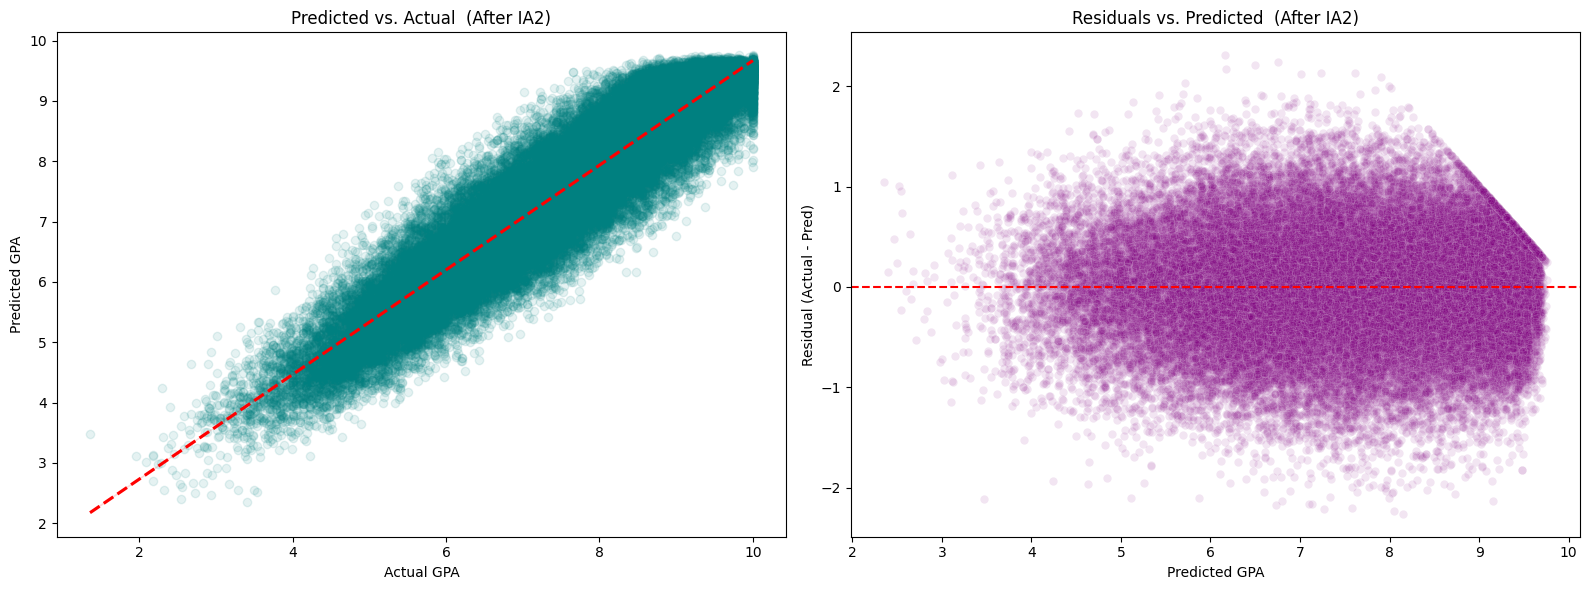

In [50]:
def plot_regression_diagnostics(y_actual, y_pred, title_suffix=""):
    # 1. Sample the data if it's too large (plotting ~50k points is enough)
    if len(y_actual) > 50000:
        idx = np.random.choice(len(y_actual), 50000, replace=False)
        y_actual_s, y_pred_s = y_actual[idx], y_pred[idx]
    else:
        y_actual_s, y_pred_s = y_actual, y_pred

    residuals = y_actual_s - y_pred_s

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Predicted vs. Actual ---
    # Ideally, points should fall on the 45-degree dashed line
    sns.regplot(x=y_actual_s, y=y_pred_s, ax=ax1, 
                scatter_kws={'alpha':0.1, 'color':'teal'}, 
                line_kws={'color':'red', 'ls':'--'})
    ax1.set_title(f'Predicted vs. Actual {title_suffix}')
    ax1.set_xlabel('Actual GPA')
    ax1.set_ylabel('Predicted GPA')

    # --- Plot 2: Residual Plot ---
    # Checks for Heteroscedasticity (uneven error distribution)
    sns.scatterplot(x=y_pred_s, y=residuals, ax=ax2, alpha=0.1, color='purple')
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title(f'Residuals vs. Predicted {title_suffix}')
    ax2.set_xlabel('Predicted GPA')
    ax2.set_ylabel('Residual (Actual - Pred)')

    plt.tight_layout()
    plt.show()

plot_regression_diagnostics(y_gpa_test, pred_after_ia2, " (After IA2)")

In [51]:
df_sample['Dropout_Flag'].value_counts()

Dropout_Flag
0    429769
1     16182
Name: count, dtype: int64

In [25]:
X_before_train = X_before_train[X_before_train.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'IA1_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                   'Assignmennt_Ratio', 'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                   'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'Performance_Volatility',
                                                                   'Shock_Magnitude', 'Shock_Event_bereavement', 'Shock_Event_breakup', 'Shock_Event_competition_success', 
                                                                   'Shock_Event_family_issue', 'Shock_Event_financial_stress', 'Shock_Event_health_problem',  'Shock_Event_none',
                                                                   'Shock_Event_mentorship_start', 'Shock_Event_part_time_job_increase', 'Shock_Event_scholarship_award'])]
X_before_test = X_before_test[X_before_test.columns.difference(['Rolling_GPA_Mean', 'IA_Average', 'Prev_GPA', 'IA2_Score', 'IA1_Score', 'Latent_Ability', 'Final_Sem_GPA',
                                                                'Assignment_Ratio', 'AttendanceRate', 'Academic_Shock', 'Severe_Academic_Shock', 'GPA_Trend', 'Engagement_Drift',
                                                                'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience', 'Performance_Volatility',
                                                                'Shock_Magnitude', 'Shock_Event_bereavement', 'Shock_Event_breakup', 'Shock_Event_competition_success', 
                                                                'Shock_Event_family_issue', 'Shock_Event_financial_stress', 'Shock_Event_health_problem',  'Shock_Event_none',
                                                                'Shock_Event_mentorship_start', 'Shock_Event_part_time_job_increase', 'Shock_Event_scholarship_award'])]

In [72]:
before_ia_logistic_dropout = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
before_ia_logistic_dropout.fit(X_before_train, y_dropout_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [74]:
pred_before = before_ia_logistic_dropout.predict(X_before_test)
print("Before IA")
print("Classification report:\n", classification_report(y_dropout_test, pred_before))
print("Accuracy:", accuracy_score(y_dropout_test, pred_before))
print("ROC AUC:", roc_auc_score(y_dropout_test, before_ia_logistic_dropout.predict_proba(X_before_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_before))

Before IA
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.90     85847
           1       0.16      0.87      0.27      3247

    accuracy                           0.82     89094
   macro avg       0.58      0.85      0.58     89094
weighted avg       0.96      0.82      0.88     89094

Accuracy: 0.8247693447370193
ROC AUC: 0.9234210479291144
Confusion matrix:
 [[70661 15186]
 [  426  2821]]


In [28]:
imbalance_ratio = 429769 / 16182 
before_ia_lgb_dropout = LGBMClassifier(n_estimators=3000, learning_rate=0.05, num_leaves=180, scale_pos_weight=imbalance_ratio, 
                                        objective='binary', metric='auc', importance_type='gain', verbose=-1)
before_ia_lgb_dropout.fit(X_before_train, y_dropout_train, eval_set=[(X_before_test, y_dropout_test)])

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32


LGBMClassifier(importance_type='gain', learning_rate=0.05, metric='auc',
               n_estimators=3000, num_leaves=180, objective='binary',
               scale_pos_weight=26.558460017303176, verbose=-1)

In [29]:
pred_before = before_ia_lgb_dropout.predict(X_before_test)
print("Before IA")
print("Classification report:\n", classification_report(y_dropout_test, pred_before))
print("Accuracy:", accuracy_score(y_dropout_test, pred_before))
print("ROC AUC:", roc_auc_score(y_dropout_test, before_ia_lgb_dropout.predict_proba(X_before_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_before))

Before IA
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     85847
           1       0.49      0.21      0.29      3247

    accuracy                           0.96     89094
   macro avg       0.73      0.60      0.64     89094
weighted avg       0.95      0.96      0.96     89094

Accuracy: 0.9631737266258109
ROC AUC: 0.8958194685957814
Confusion matrix:
 [[85144   703]
 [ 2578   669]]


In [75]:
after_ia1_logistic_gpa = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
after_ia1_logistic_gpa.fit(X_ia1_train, y_dropout_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [76]:
probs_ia1 = after_ia1_logistic_gpa.predict_proba(X_ia1_test)[:, 1]
custom_threshold = 0.40
custom_preds_ia1 = (probs_ia1 > custom_threshold).astype(int)
pred_after_ia1 = after_ia1_logistic_gpa.predict(X_ia1_test)
print("After IA1")
print("Classification report:\n", classification_report(y_dropout_test, pred_after_ia1))
print("Accuracy:", accuracy_score(y_dropout_test, pred_after_ia1))
print("ROC AUC:", roc_auc_score(y_dropout_test, after_ia1_logistic_gpa.predict_proba(X_ia1_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_after_ia1))
print("After IA1 with Cutom Threshold")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia1))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia1))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia1))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia1))

After IA1
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93     85847
           1       0.20      0.89      0.33      3247

    accuracy                           0.87     89094
   macro avg       0.60      0.88      0.63     89094
weighted avg       0.97      0.87      0.90     89094

Accuracy: 0.8666127909848026
ROC AUC: 0.9491886190589198
Confusion matrix:
 [[74315 11532]
 [  352  2895]]
After IA1 with Cutom Threshold
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91     85847
           1       0.17      0.92      0.29      3247

    accuracy                           0.83     89094
   macro avg       0.58      0.88      0.60     89094
weighted avg       0.97      0.83      0.88     89094

Accuracy: 0.8332098682290614
ROC AUC: 0.9491886190589198
Confusion matrix:
 [[71232 14615]
 [  245  3002]]


In [30]:
after_ia1_lgb_dropout = LGBMClassifier(n_estimators=3500, learning_rate=0.05, num_leaves=200, scale_pos_weight=imbalance_ratio, 
                                   objective='binary', metric='auc', importance_type='gain', verbose=-1)
after_ia1_lgb_dropout.fit(X_ia1_train, y_dropout_train, eval_set=[(X_ia1_test, y_dropout_test)])

LGBMClassifier(importance_type='gain', learning_rate=0.05, metric='auc',
               n_estimators=3500, num_leaves=200, objective='binary',
               scale_pos_weight=26.558460017303176, verbose=-1)

In [31]:
probs_ia1 = after_ia1_lgb_dropout.predict_proba(X_ia1_test)[:, 1]
custom_threshold = 0.40
custom_preds_ia1 = (probs_ia1 > custom_threshold).astype(int)
pred_after_ia1 = after_ia1_lgb_dropout.predict(X_ia1_test)
print("After IA1")
print("Classification report:\n", classification_report(y_dropout_test, pred_after_ia1))
print("Accuracy:", accuracy_score(y_dropout_test, pred_after_ia1))
print("ROC AUC:", roc_auc_score(y_dropout_test, after_ia1_lgb_dropout.predict_proba(X_ia1_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_after_ia1))
print("After IA1 with Cutom Threshold")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia1))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia1))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia1))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia1))

After IA1
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     85847
           1       0.64      0.35      0.46      3247

    accuracy                           0.97     89094
   macro avg       0.81      0.67      0.72     89094
weighted avg       0.96      0.97      0.96     89094

Accuracy: 0.9693020854378521
ROC AUC: 0.9378534215452649
Confusion matrix:
 [[85210   637]
 [ 2098  1149]]
After IA1 with Cutom Threshold
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     85847
           1       0.62      0.38      0.47      3247

    accuracy                           0.97     89094
   macro avg       0.80      0.68      0.73     89094
weighted avg       0.96      0.97      0.97     89094

Accuracy: 0.9689878106269783
ROC AUC: 0.9378534215452649
Confusion matrix:
 [[85108   739]
 [ 2024  1223]]


In [77]:
after_ia2_logistic_dropout = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
after_ia2_logistic_dropout.fit(X_ia2_train, y_dropout_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [78]:
probs_ia2 = after_ia2_logistic_dropout.predict_proba(X_ia2_test)[:, 1]
custom_threshold_1 = 0.30
custom_threshold_2 = 0.88
custom_preds_ia2_1 = (probs_ia2 > custom_threshold_1).astype(int)
custom_preds_ia2_2 = (probs_ia2 > custom_threshold_2).astype(int)
pred_after_ia2 = after_ia2_logistic_dropout.predict(X_ia2_test)
print("After IA2")
print("Classification report:\n", classification_report(y_dropout_test, pred_after_ia2))
print("Accuracy:", accuracy_score(y_dropout_test, pred_after_ia2))
print("ROC AUC:", roc_auc_score(y_dropout_test, after_ia2_logistic_dropout.predict_proba(X_ia2_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_after_ia2))
print("After IA2 with Cutom Threshold 1")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia2_1))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia2_1))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia2))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia2_1))
print("After IA2 with Cutom Threshold 2")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia2_2))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia2_2))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia2))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia2_2))

After IA2
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93     85847
           1       0.20      0.89      0.33      3247

    accuracy                           0.87     89094
   macro avg       0.60      0.88      0.63     89094
weighted avg       0.97      0.87      0.90     89094

Accuracy: 0.8666240150851909
ROC AUC: 0.9492600175954953
Confusion matrix:
 [[74311 11536]
 [  347  2900]]
After IA2 with Cutom Threshold 1
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.79      0.88     85847
           1       0.14      0.95      0.25      3247

    accuracy                           0.79     89094
   macro avg       0.57      0.87      0.57     89094
weighted avg       0.97      0.79      0.86     89094

Accuracy: 0.7940826542752598
ROC AUC: 0.9492600175954953
Confusion matrix:
 [[67674 18173]
 [  173  3074]]
After IA2 with Cutom Threshold 2
Classifi

In [32]:
#High Precision
after_ia2_lgb_dropout = LGBMClassifier(n_estimators=4000, learning_rate=0.05, num_leaves=250, scale_pos_weight=imbalance_ratio, 
               objective='binary', metric='auc', importance_type='gain', verbose=-1)
after_ia2_lgb_dropout.fit(X_ia2_train, y_dropout_train, eval_set=[(X_ia2_train, y_dropout_train), (X_ia2_test, y_dropout_test)], 
                          eval_metric='auc', callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)])               

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	training's auc: 0.983309	valid_1's auc: 0.946826


LGBMClassifier(importance_type='gain', learning_rate=0.05, metric='auc',
               n_estimators=4000, num_leaves=250, objective='binary',
               scale_pos_weight=26.558460017303176, verbose=-1)

In [33]:
probs_ia2 = after_ia2_lgb_dropout.predict_proba(X_ia2_test)[:, 1]
custom_threshold = 0.30
custom_preds_ia2 = (probs_ia2 > custom_threshold).astype(int)
pred_after_ia2 = after_ia2_lgb_dropout.predict(X_ia2_test)
print("After IA2")
print("Classification report:\n", classification_report(y_dropout_test, pred_after_ia2))
print("Accuracy:", accuracy_score(y_dropout_test, pred_after_ia2))
print("ROC AUC:", roc_auc_score(y_dropout_test, after_ia2_lgb_dropout.predict_proba(X_ia2_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_after_ia2))
print("After IA2 with Cutom Threshold")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia2))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia2))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia2))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia2))

After IA2
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95     85847
           1       0.25      0.82      0.39      3247

    accuracy                           0.91     89094
   macro avg       0.62      0.86      0.67     89094
weighted avg       0.97      0.91      0.93     89094

Accuracy: 0.90529104092307
ROC AUC: 0.9468255201473257
Confusion matrix:
 [[77999  7848]
 [  590  2657]]
After IA2 with Cutom Threshold
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92     85847
           1       0.20      0.88      0.32      3247

    accuracy                           0.86     89094
   macro avg       0.60      0.87      0.62     89094
weighted avg       0.97      0.86      0.90     89094

Accuracy: 0.8647495903203358
ROC AUC: 0.9468255201473257
Confusion matrix:
 [[74171 11676]
 [  374  2873]]


In [34]:
#High Recall
after_ia2_lgb_dropout = LGBMClassifier(n_estimators=2000, learning_rate=0.05, num_leaves=64, scale_pos_weight=imbalance_ratio,
                                   objective='binary', metric='auc', importance_type='gain', verbose=-1, min_child_samples=100,
                                   feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5)
after_ia2_lgb_dropout.fit(X_ia2_train, y_dropout_train, eval_set=[(X_ia2_train, y_dropout_train), (X_ia2_test, y_dropout_test)], 
                          eval_metric='auc', callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[110]	training's auc: 0.965707	valid_1's auc: 0.948517


LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
               importance_type='gain', learning_rate=0.05, metric='auc',
               min_child_samples=100, n_estimators=2000, num_leaves=64,
               objective='binary', scale_pos_weight=26.558460017303176,
               verbose=-1)

In [35]:
probs_ia2 = after_ia2_lgb_dropout.predict_proba(X_ia2_test)[:, 1]
custom_threshold = 0.30
custom_preds_ia2 = (probs_ia2 > custom_threshold).astype(int)
pred_after_ia2 = after_ia2_lgb_dropout.predict(X_ia2_test)
print("After IA2")
print("Classification report:\n", classification_report(y_dropout_test, pred_after_ia2))
print("Accuracy:", accuracy_score(y_dropout_test, pred_after_ia2))
print("ROC AUC:", roc_auc_score(y_dropout_test, after_ia2_lgb_dropout.predict_proba(X_ia2_test)[:, 1]))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, pred_after_ia2))
print("After IA2 with Cutom Threshold")
print("Classification report:\n", classification_report(y_dropout_test, custom_preds_ia2))
print("Accuracy:", accuracy_score(y_dropout_test, custom_preds_ia2))
print("ROC AUC:", roc_auc_score(y_dropout_test, probs_ia2))
print("Confusion matrix:\n", confusion_matrix(y_dropout_test, custom_preds_ia2))

After IA2
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93     85847
           1       0.20      0.88      0.33      3247

    accuracy                           0.87     89094
   macro avg       0.60      0.88      0.63     89094
weighted avg       0.97      0.87      0.91     89094

Accuracy: 0.8709228455339304
ROC AUC: 0.9485165841899725
Confusion matrix:
 [[74733 11114]
 [  386  2861]]
After IA2 with Cutom Threshold
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.81      0.90     85847
           1       0.16      0.94      0.27      3247

    accuracy                           0.82     89094
   macro avg       0.58      0.87      0.58     89094
weighted avg       0.97      0.82      0.87     89094

Accuracy: 0.8173277661795407
ROC AUC: 0.9485165841899725
Confusion matrix:
 [[69783 16064]
 [  211  3036]]


In [36]:
print(roc_auc_score(y_dropout_train, after_ia2_lgb_dropout.predict_proba(X_ia2_train)[:,1]))

0.9657069621869093


In [37]:
probs = after_ia2_lgb_dropout.predict_proba(X_ia2_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_dropout_test, probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.8812997428556333
Best F1: 0.5274002003147803


In [38]:
optimal_preds = (probs >= best_threshold).astype(int)
print("Classification Report:\n", classification_report(y_dropout_test, optimal_preds))
print("Confusion Matrix:\n", confusion_matrix(y_dropout_test, optimal_preds))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     85847
           1       0.49      0.57      0.53      3247

    accuracy                           0.96     89094
   macro avg       0.74      0.77      0.75     89094
weighted avg       0.97      0.96      0.96     89094

Confusion Matrix:
 [[83948  1899]
 [ 1404  1843]]


In [40]:
X_before_ia.columns

Index(['Age', 'Gender', 'SES_Quartile', 'ParentalEducation', 'SchoolType',
       'InternetAccess', 'Race_Black', 'Race_Hispanic', 'Race_Other',
       'Race_Two-or-more', 'Race_White', 'Locale_Rural', 'Locale_Suburban',
       'Locale_Town', 'first_generation_college_flag', 'Prev_GPA',
       'Rolling_GPA_Mean', 'GPA_Trend', 'Performance_Volatility',
       'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience',
       'Engagement_Drift', 'Academic_Shock', 'Severe_Academic_Shock',
       'AttendanceRate', 'StudyHours', 'Extracurricular', 'PartTimeJob',
       'ParentSupport', 'Romantic', 'FreeTime', 'GoOut',
       'study_environment_score', 'procrastination_tendency', 'sleep_hours',
       'exam_anxiety_score', 'motivation_survey_score', 'stress_survey_score',
       'self_efficacy_score', 'goal_clarity_survey_score', 'Commute_Strain',
       'Social_Distraction', 'Effort_Score', 'Support_Score',
       'Distraction_Index', 'Discipline_Score', 'Burnout_Risk', 'Support

In [41]:
X_after_ia1.columns

Index(['Age', 'Gender', 'SES_Quartile', 'ParentalEducation', 'SchoolType',
       'InternetAccess', 'Race_Black', 'Race_Hispanic', 'Race_Other',
       'Race_Two-or-more', 'Race_White', 'Locale_Rural', 'Locale_Suburban',
       'Locale_Town', 'first_generation_college_flag', 'Prev_GPA',
       'Rolling_GPA_Mean', 'GPA_Trend', 'Performance_Volatility',
       'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience',
       'Engagement_Drift', 'Academic_Shock', 'Severe_Academic_Shock',
       'AttendanceRate', 'StudyHours', 'Extracurricular', 'PartTimeJob',
       'ParentSupport', 'Romantic', 'FreeTime', 'GoOut',
       'study_environment_score', 'procrastination_tendency', 'sleep_hours',
       'exam_anxiety_score', 'motivation_survey_score', 'stress_survey_score',
       'self_efficacy_score', 'goal_clarity_survey_score', 'Commute_Strain',
       'Social_Distraction', 'Effort_Score', 'Support_Score',
       'Distraction_Index', 'Discipline_Score', 'Burnout_Risk', 'Support

In [42]:
X_after_ia2.columns 

Index(['Age', 'Gender', 'SES_Quartile', 'ParentalEducation', 'SchoolType',
       'InternetAccess', 'Race_Black', 'Race_Hispanic', 'Race_Other',
       'Race_Two-or-more', 'Race_White', 'Locale_Rural', 'Locale_Suburban',
       'Locale_Town', 'first_generation_college_flag', 'Prev_GPA',
       'Rolling_GPA_Mean', 'GPA_Trend', 'Performance_Volatility',
       'Cumulative_Academic_Risk', 'Risk_Acceleration', 'Learning_Resilience',
       'Engagement_Drift', 'Academic_Shock', 'Severe_Academic_Shock',
       'AttendanceRate', 'StudyHours', 'Extracurricular', 'PartTimeJob',
       'ParentSupport', 'Romantic', 'FreeTime', 'GoOut',
       'study_environment_score', 'procrastination_tendency', 'sleep_hours',
       'exam_anxiety_score', 'motivation_survey_score', 'stress_survey_score',
       'self_efficacy_score', 'goal_clarity_survey_score', 'Commute_Strain',
       'Social_Distraction', 'Effort_Score', 'Support_Score',
       'Distraction_Index', 'Discipline_Score', 'Burnout_Risk', 'Support

In [32]:
before_ia_archetype_lgb = LGBMClassifier(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.8, num_class=7,
                                         max_depth=6, objective='multiclass', verbose=-1, class_weight='balanced')
before_ia_archetype_lgb.fit(X_before_train, y_archetype_train)         
archetype_probs = before_ia_archetype_lgb.predict_proba(X_before_test)   

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = 

In [33]:
pred_before = before_ia_archetype_lgb.predict(X_before_test)
print("Before IA")
print("Classification report:\n", classification_report(y_archetype_test, pred_before))
print("Accuracy:", accuracy_score(y_archetype_test, pred_before))
print("Confusion matrix:\n", confusion_matrix(y_archetype_test, pred_before))

Before IA
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.97      0.98     15575
       elite       1.00      0.98      0.99     13264
 fading_star       0.93      1.00      0.97      8792
late_bloomer       0.94      0.93      0.93     14967
  pragmatist       0.95      0.91      0.93     23568
  vulnerable       0.91      1.00      0.95     12928

    accuracy                           0.96     89094
   macro avg       0.96      0.96      0.96     89094
weighted avg       0.96      0.96      0.96     89094

Accuracy: 0.9559005095741576
Confusion matrix:
 [[15112     0     0     0     0   463]
 [    0 12988     0   276     0     0]
 [    0     6  8785     0     1     0]
 [    0     0     0 13920  1025    22]
 [    0     3   613   675 21439   838]
 [    4     0     0     0     3 12921]]


In [49]:
all_preds = []
all_trues = []

for train_fold, val_fold in temporal_folds:
    X_train = X_before_ia.loc[train_fold]
    X_val   = X_before_ia.loc[val_fold]

    y_train = y_archetype.loc[train_fold]
    y_val   = y_archetype.loc[val_fold]

    before_ia_archetype_lgb.fit(X_train, y_train)

    preds = before_ia_archetype_lgb.predict(X_val)
    
    all_preds.extend(preds)
    all_trues.extend(y_val)

In [50]:
print("Temporal CV Before IA Results")
print("Classification report:\n", classification_report(all_trues, all_preds))
print("Accuracy:", accuracy_score(all_trues, all_preds))
print("Confusion matrix:\n", confusion_matrix(all_trues, all_preds))

Temporal CV Before IA Results
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.96      0.98     43550
       elite       1.00      0.98      0.99     40187
 fading_star       0.95      1.00      0.97     23754
late_bloomer       0.93      0.92      0.92     44511
  pragmatist       0.95      0.92      0.94     73570
  vulnerable       0.90      1.00      0.94     32708

    accuracy                           0.95    258280
   macro avg       0.95      0.96      0.96    258280
weighted avg       0.96      0.95      0.95    258280

Accuracy: 0.9539569459501316
Confusion matrix:
 [[41946     0     0     0     1  1603]
 [    0 39262     0   924     1     0]
 [    0    22 23708     0    24     0]
 [    0    28     0 40966  3454    63]
 [    0    22  1180  2360 67881  2127]
 [   52     0     0     1    30 32625]]


In [34]:
after_ia1_archetype_lgb = LGBMClassifier(objective='multiclass', num_class=7, n_estimators=800, learning_rate=0.05, max_depth=6,  
                                          class_weight='balanced', importance_type='gain', verbose=-1)
after_ia1_archetype_lgb.fit(X_ia1_archetype_train, y_archetype_train)    

LGBMClassifier(class_weight='balanced', importance_type='gain',
               learning_rate=0.05, max_depth=6, n_estimators=800, num_class=7,
               objective='multiclass', verbose=-1)

In [35]:
pred_after_ia1 = after_ia1_archetype_lgb.predict(X_ia1_archetype_test)
print("After IA1")
print("Classification report:\n", classification_report(y_archetype_test, pred_after_ia1))
print("Accuracy:", accuracy_score(y_archetype_test, pred_after_ia1))
print("Confusion matrix:\n", confusion_matrix(y_archetype_test, pred_after_ia1))

After IA1
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.97      0.98     15575
       elite       1.00      0.98      0.99     13264
 fading_star       0.93      0.99      0.96      8792
late_bloomer       0.94      0.93      0.93     14967
  pragmatist       0.95      0.91      0.93     23568
  vulnerable       0.91      1.00      0.95     12928

    accuracy                           0.95     89094
   macro avg       0.95      0.96      0.96     89094
weighted avg       0.96      0.95      0.95     89094

Accuracy: 0.9548678923384291
Confusion matrix:
 [[15112     0     0     0     0   463]
 [    0 12988     0   276     0     0]
 [    0     6  8735     1    50     0]
 [    0     1     0 13919  1025    22]
 [    0     3   639   681 21404   841]
 [    7     0     0     1     5 12915]]


In [51]:
all_preds = []
all_trues = []

for train_fold, val_fold in temporal_folds:
    X_train = X_after_ia1_archetype.loc[train_fold]
    X_val   = X_after_ia1_archetype.loc[val_fold]

    y_train = y_archetype.loc[train_fold]
    y_val   = y_archetype.loc[val_fold]

    after_ia1_archetype_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='multi_logloss', 
                               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

    preds = after_ia1_archetype_lgb.predict(X_val, num_iteration=after_ia1_archetype_lgb.best_iteration_)
    
    all_preds.extend(preds)    
    all_trues.extend(y_val)

In [52]:
print("Temporal CV After IA1 Results")
print("Classification report:\n", classification_report(all_trues, all_preds))
print("Accuracy:", accuracy_score(all_trues, all_preds))
print("Confusion matrix:\n", confusion_matrix(all_trues, all_preds))

Temporal CV After IA1 Results
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.96      0.98     43550
       elite       1.00      0.98      0.99     40187
 fading_star       0.94      0.99      0.97     23754
late_bloomer       0.93      0.92      0.92     44511
  pragmatist       0.95      0.92      0.93     73570
  vulnerable       0.90      1.00      0.94     32708

    accuracy                           0.95    258280
   macro avg       0.95      0.96      0.96    258280
weighted avg       0.95      0.95      0.95    258280

Accuracy: 0.9529967477156575
Confusion matrix:
 [[41937     0     0     0     0  1613]
 [    0 39259     0   928     0     0]
 [    0    23 23571     4   156     0]
 [    0     3    18 40989  3439    62]
 [    0    22  1357  2361 67694  2136]
 [   13     0     1     4     0 32690]]


In [36]:
after_ia2_archetype_lgb = LGBMClassifier(objective='multiclass', num_class=7, n_estimators=800, learning_rate=0.05, max_depth=6,
                                         class_weight='balanced', importance_type='gain', verbose=-1)
after_ia2_archetype_lgb.fit(X_ia2_archetype_train, y_archetype_train)  

LGBMClassifier(class_weight='balanced', importance_type='gain',
               learning_rate=0.05, max_depth=6, n_estimators=800, num_class=7,
               objective='multiclass', verbose=-1)

In [37]:
pred_after_ia2 = after_ia2_archetype_lgb.predict(X_ia2_archetype_test)
print("After IA2")
print("Classification report:\n", classification_report(y_archetype_test, pred_after_ia2))
print("Accuracy:", accuracy_score(y_archetype_test, pred_after_ia2))
print("Confusion matrix:\n", confusion_matrix(y_archetype_test, pred_after_ia2))

After IA2
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.97      0.98     15575
       elite       1.00      0.98      0.99     13264
 fading_star       0.89      0.95      0.92      8792
late_bloomer       0.94      0.93      0.93     14967
  pragmatist       0.93      0.89      0.91     23568
  vulnerable       0.91      0.99      0.95     12928

    accuracy                           0.95     89094
   macro avg       0.94      0.95      0.95     89094
weighted avg       0.95      0.95      0.95     89094

Accuracy: 0.9455967854176488
Confusion matrix:
 [[15110     0     0     0     1   464]
 [    0 12986     0   277     1     0]
 [    0     6  8388     2   384    12]
 [    0     6    15 13915  1010    21]
 [    2     3  1022   672 21020   849]
 [   18     0     8     1    73 12828]]


In [53]:
all_preds = []
all_trues = []

for train_fold, val_fold in temporal_folds:
    X_train = X_after_ia2_archetype.loc[train_fold]
    X_val   = X_after_ia2_archetype.loc[val_fold]

    y_train = y_archetype.loc[train_fold]
    y_val   = y_archetype.loc[val_fold]

    after_ia2_archetype_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='multi_logloss', 
                               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

    preds = after_ia2_archetype_lgb.predict(X_val, num_iteration=after_ia2_archetype_lgb.best_iteration_)
    
    all_preds.extend(preds)    
    all_trues.extend(y_val)

In [54]:
print("Temporal CV After IA1 Results")
print("Classification report:\n", classification_report(all_trues, all_preds))
print("Accuracy:", accuracy_score(all_trues, all_preds))
print("Confusion matrix:\n", confusion_matrix(all_trues, all_preds))

Temporal CV After IA1 Results
Classification report:
               precision    recall  f1-score   support

  disengaged       1.00      0.96      0.98     43550
       elite       1.00      0.98      0.99     40187
 fading_star       0.80      0.96      0.88     23754
late_bloomer       0.93      0.92      0.92     44511
  pragmatist       0.93      0.86      0.90     73570
  vulnerable       0.89      0.98      0.93     32708

    accuracy                           0.93    258280
   macro avg       0.92      0.94      0.93    258280
weighted avg       0.94      0.93      0.93    258280

Accuracy: 0.9317988229828094
Confusion matrix:
 [[41915     0     0     0     4  1631]
 [    0 39247     8   931     1     0]
 [    3    22 22805    10   870    44]
 [    0    30   105 40958  3361    57]
 [    5    26  5396  2349 63633  2161]
 [   65     0    39     5   492 32107]]


In [38]:
def generate_risk_migration(df, start_col, end_col):
    rank_map = {2: 6, 4: 5, 5: 4, 3: 3, 0: 2, 6: 1, 1: 0}
    label_map = {0: 'Disengaged', 1: 'Dropped Out', 2: 'Elite', 3: 'Fading Star', 
                 4: 'Late Bloomer', 5: 'Pragmatist', 6: 'Vulnerable'}

    df['start_rank'] = df[start_col].map(rank_map)
    df['end_rank'] = df[end_col].map(rank_map)
    
    conditions = [
        (df['end_rank'] > df['start_rank']),
        (df['end_rank'] < df['start_rank']),
        (df['end_rank'] == df['start_rank'])
    ]
    choices = ['Improved', 'Declined', 'Stable']
    
    df['migration_dir'] = np.select(conditions, choices, default='Stable')
    
    # 1. Generate the cross-tabulation
    migration_summary = df.groupby(start_col)['migration_dir'].value_counts(normalize=True).unstack().fillna(0) * 100
    
    # 2. SAFETY GATE: Add missing columns if they don't exist
    for column_name in ['Stable', 'Improved', 'Declined']:
        if column_name not in migration_summary.columns:
            migration_summary[column_name] = 0.0  # Fill with 0% if the movement never happened

    # 3. Map the index to names
    migration_summary.index = migration_summary.index.map(label_map)
    
    # 4. Reorder and return
    return migration_summary[['Stable', 'Improved', 'Declined']].round(6)

df_results = pd.DataFrame(index=X_before_test.index)
df_results['pred_before_ia'] = before_ia_archetype_lgb.predict(X_before_test)
df_results['pred_after_ia1'] = after_ia1_archetype_lgb.predict(X_ia1_archetype_test)
df_results['pred_after_ia2'] = after_ia2_archetype_lgb.predict(X_ia2_archetype_test)

In [39]:
risk_table1 = generate_risk_migration(df_results, 'pred_before_ia', 'pred_after_ia2')
risk_table2 = generate_risk_migration(df_results, 'pred_before_ia', 'pred_after_ia1')
risk_table3 = generate_risk_migration(df_results, 'pred_after_ia1', 'pred_after_ia2')
print("Risk Table 1:\n", risk_table1)
print("Risk Table 2:\n", risk_table2)
print("Risk Table 3:\n", risk_table3)

Risk Table 1:
 migration_dir   Stable  Improved  Declined
pred_before_ia                            
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
Risk Table 2:
 migration_dir   Stable  Improved  Declined
pred_before_ia                            
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
Risk Table 3:
 migration_dir   Stable  Improved  Declined
pred_after_ia1                            
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN              100.0       0.0       0.0
NaN      

In [40]:
archetype_names = ['Disengaged', 'Dropped Out', 'Elite', 'Fading Star', 'Late Bloomer', 'Pragmatist', 'Vulnerable']
def plot_transition_matrix(before_labels, after_labels, title="Archetype Transition Matrix"):
    # Create the matrix
    matrix = pd.crosstab(before_labels, after_labels, normalize='index')     
    plt.figure(figsize=(12, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=archetype_names, 
                yticklabels=archetype_names)    
    plt.title(title)
    plt.ylabel('Initial State (Before IA)')
    plt.xlabel('Updated State (After IA1)')
    plt.show()

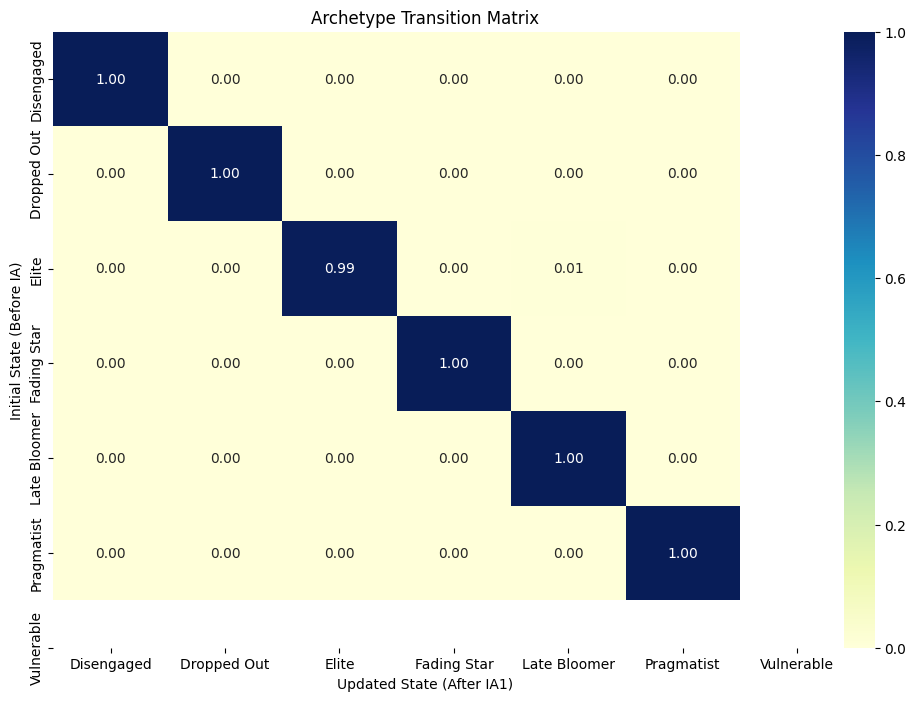

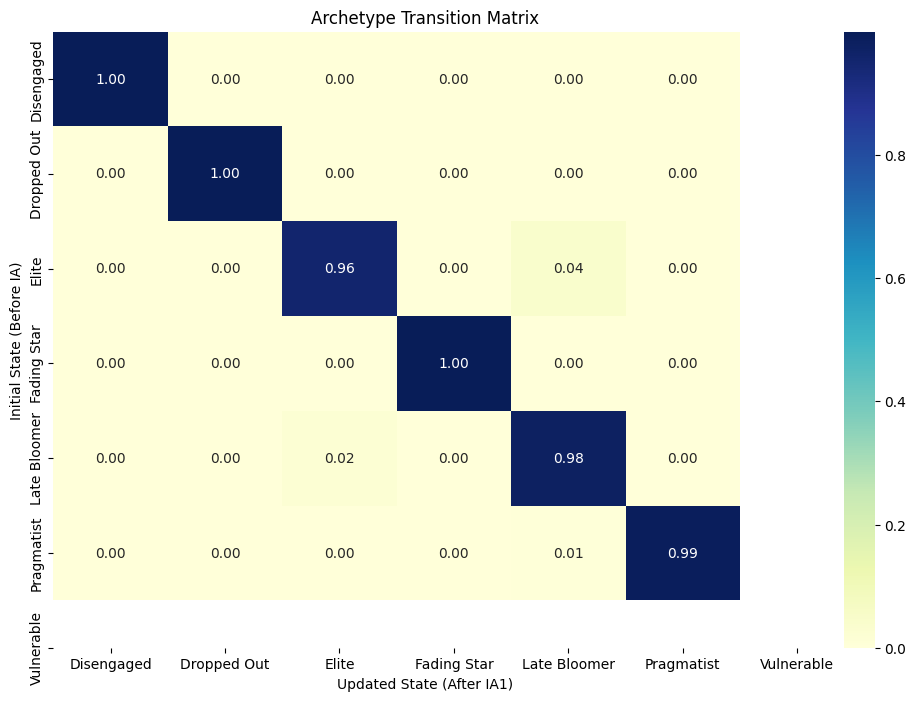

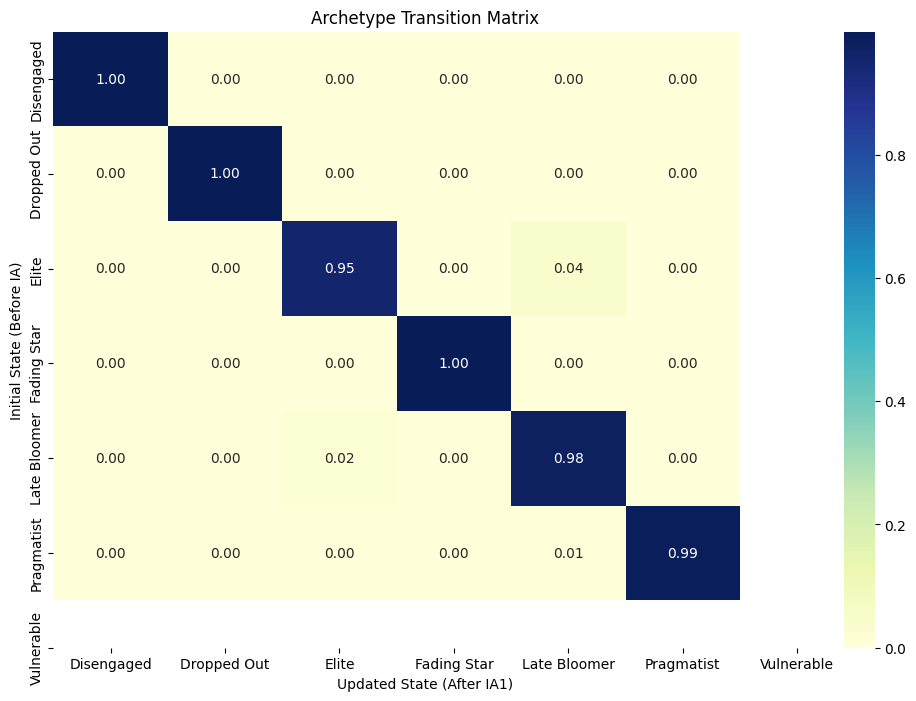

In [41]:
plot_transition_matrix(df_results['pred_before_ia'], df_results['pred_after_ia1'])
plot_transition_matrix(df_results['pred_before_ia'], df_results['pred_after_ia2'])
plot_transition_matrix(df_results['pred_after_ia1'], df_results['pred_after_ia2'])

In [42]:
def analyze_drift(df, before_col, after_col):
    # Calculate who stayed vs who moved
    df['drift_status'] = np.where(df[before_col] == df[after_col], 'Stable', 'Drifted')
    drift_counts = df.groupby(before_col)['drift_status'].value_counts(normalize=True).unstack()
    print("Stability vs Drift by Archetype:")
    print(drift_counts.sort_values(by='Drifted', ascending=False))
    return drift_counts

In [43]:
analysis = analyze_drift(df_results, 'pred_before_ia', 'pred_after_ia1')
analysis = analyze_drift(df_results, 'pred_before_ia', 'pred_after_ia2')
analysis = analyze_drift(df_results, 'pred_after_ia1', 'pred_after_ia2')

Stability vs Drift by Archetype:
drift_status     Drifted    Stable
pred_before_ia                    
fading_star     0.005427  0.994573
pragmatist      0.001825  0.998175
vulnerable      0.000913  0.999087
late_bloomer    0.000471  0.999529
disengaged      0.000397  0.999603
elite                NaN  1.000000
Stability vs Drift by Archetype:
drift_status     Drifted    Stable
pred_before_ia                    
fading_star     0.044052  0.955948
pragmatist      0.020696  0.979304
vulnerable      0.008144  0.991856
late_bloomer    0.000740  0.999260
disengaged      0.000662  0.999338
elite           0.000154  0.999846
Stability vs Drift by Archetype:
drift_status     Drifted    Stable
pred_after_ia1                    
fading_star     0.045231  0.954769
pragmatist      0.022327  0.977673
vulnerable      0.007935  0.992065
late_bloomer    0.001277  0.998723
disengaged      0.000661  0.999339
elite           0.000231  0.999769
